In [19]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT = '/content/drive/MyDrive/Customer-Retention-Segmentation-Uplift'
os.makedirs(f'{PROJECT}/data', exist_ok=True)
os.makedirs(f'{PROJECT}/processed', exist_ok=True)
os.makedirs(f'{PROJECT}/models', exist_ok=True)
os.makedirs(f'{PROJECT}/figures', exist_ok=True)
print(PROJECT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Customer-Retention-Segmentation-Uplift


In [21]:
txn = pd.read_parquet(f'{PROJECT}/processed/transactions.parquet')
print(txn.shape)

(8045229, 10)


## 1. Business Problem

### 1.1 Description

X5 Retail Group is one of the largest food retailers in Russia. It runs a
loyalty program across thousands of stores. Customers get a card, shop when
they want, and are never asked to cancel anything.

This is the problem. Netflix knows when you leave, because you click cancel.
A shop does not. Customers just stop coming back one day. Nobody announces it.
All you see is silence. A customer who has left and a customer who is simply
between trips look identical in the data.

While reviewing Q1 2026 public filings and earnings materials from DoorDash,
Uber and Expedia, I found that none of them reported a standardized churn rate
for their core marketplace. This is not an oversight. Ordinary marketplace
customers do not formally cancel, so churn has to be inferred from inactivity
or declining transaction behavior rather than observed directly, and there is
no single accepted definition of it to disclose.

The absence of a publicly reported churn rate does not mean these companies do
not measure churn internally. They may well track cohort retention, repeat
transaction rates, inactivity, reactivation and predicted churn risk to inform
product and retention decisions. Public reporting and internal measurement are
different things. Membership programs are the exception, because renewal and
cancellation are directly observable events, which is why retention narratives
in these disclosures tend to centre on membership rather than on the
marketplace itself.

This project works on the inference problem itself. Because no cancellation
event exists, churn cannot be read directly and would normally have to be
inferred using a threshold someone chooses. This project avoids that. The
campaign included a randomised control group who received nothing, and for
those customers the data records whether they purchased in the following
period. That is an observed retention outcome, not an inferred one, and it
requires no threshold to defend. The project then separates customers at risk
of lapsing from customers whose behaviour an offer can actually change.

> Credits: X5 Retail Group / RetailHero.ai

### 1.2 Problem Statement

* Build a churn label from purchase behaviour, since none exists in the data.
* Group customers into behavioural segments.
* Predict which customers are likely to stop buying.
* Estimate which customers will buy more because of an offer, rather than those
  who would have bought anyway.
* Rank customers so a fixed retention budget can be spent on the highest-value
  targets.


### 1.3 Sources / Useful Links

* Dataset: https://ods.ai/competitions/x5-retailhero-uplift-modeling
* Kaggle mirror: https://www.kaggle.com/datasets/dmitryuarov/x5-retail-hero
* scikit-uplift library: https://www.uplift-modeling.com


### 1.4 Real-world/Business objectives and constraints

* A single fixed inactivity threshold is not valid. Silence must be measured
  relative to each customer's own purchase rhythm.
* Errors are costly in both directions. Contacting someone who was never leaving
  wastes budget. Missing someone who leaves loses their future spending.
* Probability scores are needed, not hard labels, so the cut-off can move with
  the available budget.
* Interpretability is important. Segments must be describable in plain language
  and targeting decisions must be explainable to a retention team.
* The treatment effect cannot be observed for an individual customer, so
  intervention performance must be evaluated across groups.


### 1.5 Business KPIs

**1. Extra purchases from the offer**

How many more people bought because of the message, not in total.

    Extra purchases = purchase rate (got offer) − purchase rate (no offer)

**2. Extra purchases at a fixed budget — three ways**

Same budget, same number of offers, three ways of choosing who receives them:
at random, by highest churn risk, or by highest predicted response. This
comparison is the main result of the project.

**3. Cost per extra purchase**

    Cost per extra purchase = money spent / extra purchases

**4. Wasted spend**

The share of offers going to people who would have bought anyway, estimated
from the control group.

**5. Response by customer segment**

Whether some behavioural segments respond better than others. This is where
the segmentation earns its place.

**6. Money at risk**

Total normal spending of customers flagged as likely to leave, broken down by
segment.


### 1.6 KPIs that cannot be measured with this data

A real retention team would also track the numbers below. We cannot, because
the data records only **whether** a customer bought after the campaign, not how
much they spent or how many times.

* Extra revenue
* Contribution margin and campaign ROI
* Extra purchase frequency
* Extra average basket size
* Customer lifetime value saved

All of these need money amounts or order counts after the campaign. We have
only a yes or no.

They are listed to show what the full version looks like. With revenue data,
contribution margin per 1,000 customers contacted would be the primary KPI.

## 2. Machine Learning Problem Formulation

### 2.1. Data

#### 2.1.1. Data Overview

Source: https://ods.ai/competitions/x5-retailhero-uplift-modeling

We have five data files. Four describe customer behaviour before a promotional
SMS campaign, and one records the campaign itself along with its outcome.

All files share a common column called `client_id`.

Data file's information:

        clients        (client_id, first_issue_date, first_redeem_date, age, gender)
        purchases      (client_id, transaction_id, transaction_datetime, purchase_sum,
                    store_id, product_id, product_quantity, points earned/spent)
        train          (client_id) with treatment_flg and target held separately

The scikit-uplift distribution does not include the product category file, so
only `product_id` is available. Distinct products can be counted, but not
distinct categories.

Two points that shape the whole project:

* `purchases` contains only transactions from **before** the SMS was sent. What
  happened afterwards is available only as the binary `target` column.
* `treatment_flg` indicates whether the customer received the SMS. Assignment
  was random, which is what makes causal estimation possible.

There is no churn column in any file. It must be constructed.

#### 2.1.2. Example Data Point

**clients**

    client_id,first_issue_date,first_redeem_date,age,gender
    000012768d,2017-08-05 15:40:48,2018-01-04 19:30:07,45,U
    000036f903,2017-04-10 13:54:23,2017-04-23 12:37:56,72,F

**purchases**

    client_id,transaction_id,transaction_datetime,purchase_sum,store_id,product_id,product_quantity
    000012768d,09497b1c36,2018-12-01 07:12:45,1007.0,3d1a09c8f5,1b2c5e42a0,1.0
    000012768d,09497b1c36,2018-12-01 07:12:45,1007.0,3d1a09c8f5,4e7f0d9b13,2.0

Note that a transaction spans multiple rows, one per product.

**products**

    product_id,level_1,level_2,level_3,level_4,is_own_trademark,is_alcohol
    1b2c5e42a0,f2a1b0,c93d47,88e0a2,5c7f11,0,0

**uplift_train**

    client_id,treatment_flg,target
    000012768d,1,1
    000036f903,0,0
    00010925a5,1,0

The column values above are illustrative. Actual values, row counts and date
ranges are printed from the files in section 3.

### 2.2. Mapping the real-world problem to an ML problem

#### 2.2.1. Type of Machine Learning Problem

This maps to three ML problems solved in sequence.

**Layer 1 — Segmentation.** Unsupervised clustering. Group customers by
purchase behaviour. No ground truth exists.

**Layer 2 — Retention.** Binary classification on an observed outcome => will
this customer fail to return in the next period without intervention? The label is the control group's `target`, where 0 records a customer who did not purchase after the campaign having received no message.

**Layer 3 — Uplift modelling.** Supervised models applied to a causal question.
Estimate the conditional average treatment effect


τ(x) = E[Y(1)|X] − E[Y(0)|X].


Standard classifiers are used as base learners inside a meta-learner
(T-learner, X-learner) or a causal forest, but the quantity being estimated is
a difference between two potential outcomes. Only one of Y(1) or Y(0) is ever
observed per customer, so there is no per-customer ground truth and
classification metrics do not apply.

#### 2.2.2. Performance Metric

Source: https://ods.ai/competitions/x5-retailhero-uplift-modeling

Metric(s):

**Layer 1 — Segmentation**

* Silhouette score
* Elbow method (inertia)
* Segment size distribution

**Layer 2 — Retention**

* PR-AUC (average precision)
* Precision@k and Recall@k
* ROC-AUC (reference only)
* Confusion matrix

Accuracy is not used. With a minority positive class it is maximised by a
trivial always-negative predictor.

**Layer 3 — Uplift**

* Qini coefficient
* AUUC
* Uplift by decile

Accuracy, ROC-AUC, F1, precision and recall do not apply, as no per-customer
label for τ(x) exists.

#### 2.2.3. Machine Learning Objectives and Constraints

**Objective:** Predict, for each customer, the probability of not returning in
the next period without intervention,  and the expected change in purchase probability caused by an offer, and rank customers
by expected value under a fixed budget.

**Constraints:**

* The purchase window is only 117 days, too short to derive an inactivity
  threshold from observed return rates. The control group's post-campaign
  outcome is used as the label instead.
* Inactivity must be measured relative to each customer's own purchase rhythm,
  not a fixed threshold.
* Class probabilities are needed, not hard labels => the cut-off must move with
  the budget.
* Errors are costly in both directions => threshold selection must reflect the
  cost of each.
* Individual treatment effect is unobservable => uplift must be evaluated on
  groups, using Qini rather than classification metrics.
* Interpretability is required => segments must be nameable and targeting
  decisions explainable.
* No latency constraints => batch scoring weekly or monthly is sufficient.
* No feature may derive from post-campaign events => leakage would invalidate
  the causal estimate.
* The purchase history covers only 117 days, which is too short to construct a
  reliable inactivity threshold from observed return rates. The control group's
  post-campaign outcome is used as the inactivity label instead. This measures
  near-term lapse rather than permanent churn.

### 2.3. Train and Test Construction

The split differs by layer. A random split is not valid for Layer 2.

### 2.3. Train and Test Construction

**Layer 2 — Retention.** The purchase history spans only 117 days, too short to
construct an inactivity label by splitting it in time. Instead, the control
group's post-campaign outcome is used as the label: for the 100,058 customers
who received no message, `target = 0` is a directly observed record of not
purchasing without intervention. Features come from the purchase history, the
label from the campaign outcome, so the two are already separated in time. A
stratified random split is used for train/test.

**Layer 3 — Uplift.** Stratified random split of the campaign data, stratified
jointly on `treatment_flg` and `target` so both the treatment ratio and the
outcome rate are preserved. Both treated and control customers must appear in
the held-out set, since Qini compares the two groups within each ranked slice.

In [5]:
!pip install scikit-uplift -q

from sklift.datasets import fetch_x5
data = fetch_x5(data_home=f'{PROJECT}/data')
print(data.keys())

Part 1: X5 train:   0%|          | 0.00/1.18M [00:00<?, ?iB/s]

Part 2: X5 clients:   0%|          | 0.00/7.64M [00:00<?, ?iB/s]

Part 3: X5 purchases:   0%|          | 0.00/670M [00:00<?, ?iB/s]

dict_keys(['data', 'target', 'treatment', 'DESCR', 'feature_names', 'target_name', 'treatment_name'])


In [6]:
print(type(data.data))
print(data.data.keys() if hasattr(data.data, 'keys') else data.data.shape)

<class 'sklearn.utils._bunch.Bunch'>
dict_keys(['clients', 'train', 'purchases'])


In [9]:
for name in ['clients', 'train', 'purchases']:
  df = getattr(data.data, name, None)
  if df is not None:
    print(f'\n=== {name} ===')
    print("Shape : ", df.shape)
    print("Types : ", df.dtypes)
    print(df.head(3))


=== clients ===
Shape :  (400162, 5)
Types :  client_id            object
first_issue_date     object
first_redeem_date    object
age                   int64
gender               object
dtype: object
    client_id     first_issue_date    first_redeem_date  age gender
0  000012768d  2017-08-05 15:40:48  2018-01-04 19:30:07   45      U
1  000036f903  2017-04-10 13:54:23  2017-04-23 12:37:56   72      F
2  000048b7a6  2018-12-15 13:33:11                  NaN   68      F

=== train ===
Shape :  (200039, 1)
Types :  client_id    object
dtype: object
    client_id
0  000012768d
1  000036f903
2  00010925a5

=== purchases ===
Shape :  (45786568, 13)
Types :  client_id                   object
transaction_id              object
transaction_datetime        object
regular_points_received    float64
express_points_received    float64
regular_points_spent       float64
express_points_spent       float64
purchase_sum               float64
store_id                    object
product_id               

**Clients Observations**

* There are 400,162 customers in the loyalty database, but only 200,039 appear
  in the campaign. So roughly half were included in the experiment.
* `first_issue_date` and `first_redeem_date` are stored as text, not dates.
  They must be converted before any time calculation.
* `first_redeem_date` is missing for some customers. This is not a data error.
  It means the customer never redeemed loyalty points, which is itself a signal
  worth keeping as a feature.
* `gender` contains a value `U` alongside `F` and `M`, so it is not binary.
* `age` is already numeric. It should be checked for impossible values before
  use.



** Train Observations**

* The campaign covers 200,039 customers, exactly half the loyalty base.
* This file contains only `client_id`. The treatment flag and the outcome are
  held separately and must be joined on this key.
* Every customer in this file needs features built from their purchase history.
  Any customer with no purchases before the campaign will need handling.


**Purchases Observations**

* 45.8 million rows, but these are not 45.8 million purchases. Each row is one
  product within a transaction.
* Look at the first three rows. Same `client_id`, same `transaction_id`, same
  timestamp, same `purchase_sum` of 1007. One shopping trip split across three
  product lines.
* This means `purchase_sum` is repeated on every row of a transaction. Summing
  it directly would multiply the true spend by the number of items bought.
* The data must therefore be collapsed twice: first to one row per transaction,
  then to one row per customer.
* `transaction_datetime` is text and must be converted, specifying the format
  explicitly. Inferring it row by row across 45 million rows is very slow.
* `trn_sum_from_red` is mostly null, which likely indicates the portion of the
  bill paid with loyalty points. Null means none was used.
* There is no product category file in this download. Only `product_id` is
  available, so we can count distinct products but not distinct categories.

In [10]:
print(data.target.shape, data.target_name)
print(data.treatment.shape, data.treatment_name)
print(data.treatment.value_counts())
print(data.target.value_counts())

(200039,) target
(200039,) treatment_flg
treatment_flg
0    100058
1     99981
Name: count, dtype: int64
target
1    124002
0     76037
Name: count, dtype: int64


**Observations**

* The split is 100,058 control against 99,981 treated. Almost exactly half and
  half, which is what a properly randomised experiment looks like.
* This balance is what makes causal estimation possible. Without it, any
  difference between the groups could be explained by who was chosen rather
  than by the message.
* The outcome is 124,002 buyers against 76,037 non-buyers, so 62% purchased.
* The campaign outcome is therefore **not** an imbalanced problem. The class balance of the retention label is checked separately, since it uses only the control group.

In [11]:
import pandas as pd

t = pd.DataFrame({'treatment' : data.treatment, 'target' : data.target})
rates = t.groupby('treatment')['target'].mean()
print(rates)
print('Naive uplift : ', rates[1] - rates[0])

treatment
0    0.603280
1    0.636511
Name: target, dtype: float64
Naive uplift :  0.03323083953462003


**Observations**

* 60.3% of the control group purchased without receiving anything.
* 63.7% of the treated group purchased.
* The difference is 3.32 percentage points. This is the average effect of the
  SMS across all customers, and it is the number the rest of the project must
  beat.
* Sent to 100,000 people, this represents roughly 3,300 extra purchases.
* The effect is small, and that is the point. Most customers were going to
  behave the same way regardless of the message. The responsive minority is
  buried inside the 200,000 and finding them is the task.
* The 60.3% base rate also means a blanket campaign would spend most of its
  budget on customers who needed no encouragement at all. This is the wasted
  spend the targeting model exists to reduce.

In [12]:
purchases = data.data.purchases

purchases['transaction_datetime'] = pd.to_datetime(
    purchases['transaction_datetime'], format = '%Y-%m-%d %H:%M:%S'
)

print(purchases['transaction_datetime'].min(),
      purchases['transaction_datetime'].max())

2018-11-21 21:02:33 2019-03-18 23:40:03


In [16]:
txn = (purchases
    .groupby(['client_id', 'transaction_id'], sort=False)
    .agg(
        txn_date=('transaction_datetime', 'first'),
        txn_sum=('purchase_sum', 'first'),
        store=('store_id', 'first'),
        n_items=('product_id', 'nunique'),
        qty=('product_quantity', 'sum'),
        pts_recv=('regular_points_received', 'first'),
        pts_spent=('regular_points_spent', 'first'),
        from_red=('trn_sum_from_red', 'first'),
    )
    .reset_index())

txn.to_parquet(f'{PROJECT}/processed/transactions.parquet')
print(txn.shape)
txn.head()

(8045229, 10)


,client_id,transaction_id,txn_date,txn_sum,store,n_items,qty,pts_recv,pts_spent,from_red
0,000012768d,7e3e2e3984,2018-12-01 07:12:45,1007.0,54a4a11a29,19,21.0,10.0,0.0,NaN
1,000012768d,c1ca85d462,2018-12-16 08:56:01,574.0,ed8d2683fd,11,14.0,5.7,0.0,NaN
2,000012768d,6a0e96d0bc,2019-03-08 10:12:03,803.0,017c89b915,16,13.0,8.0,0.0,NaN
3,000012768d,b34f23306e,2019-03-14 15:01:47,419.0,017c89b915,6,6.0,2.0,0.0,NaN
4,000036f903,12b218b054,2018-11-28 10:48:36,241.0,6381a55c22,5,4.0,1.2,0.0,NaN


In [17]:
del purchases
import gc; gc.collect()

12337

In [13]:
print('Span (days):', (purchases['transaction_datetime'].max()
                     - purchases['transaction_datetime'].min()).days)

txn_dates = purchases.groupby('client_id')['transaction_datetime'].agg(['min','max','count'])
print(txn_dates['count'].describe())
print('Customers with 1 transaction:', (txn_dates['count']==1).sum())

Span (days): 117
count    400162.000000
mean        114.420080
std         103.553745
min           1.000000
25%          43.000000
50%          85.000000
75%         153.000000
max        2513.000000
Name: count, dtype: float64
Customers with 1 transaction: 763


**Observations**

* The purchase history covers 117 days, from 2018-11-21 to 2019-03-18. This is
  a four-month snapshot, not a complete customer history.
* Loyalty cards in `clients.csv` were issued as far back as 2017, so account
  tenure must be taken from `first_issue_date`, not from the earliest
  transaction seen here.
* 117 days is too short to build a return-rate curve. Asking how many customers
  return after 90 days of silence would require a much longer follow-up window
  than the data provides. The inactivity label therefore comes from the control
  group's campaign outcome rather than from a silence threshold.
* The counts above are **product rows**, not shopping trips. A single
  transaction appears once per item purchased, so a median of 85 rows does not
  mean 85 visits.
* Only 763 customers have a single product row, so almost every customer has
  some activity to build features from.
* The maximum of 2,513 product rows for one customer is worth noting as a
  possible outlier and should be checked before features are scaled.

In [14]:
txn_per_client = (purchases
    .groupby('client_id')['transaction_id']
    .nunique())

print(txn_per_client.describe())
print('\n1 transaction :', (txn_per_client == 1).sum())
print('2 transactions:', (txn_per_client == 2).sum())
print('<5 transactions:', (txn_per_client < 5).sum())

count    400162.000000
mean         20.104930
std          17.729177
min           1.000000
25%           8.000000
50%          15.000000
75%          27.000000
max         320.000000
Name: transaction_id, dtype: float64

1 transaction : 7707
2 transactions: 11078
<5 transactions: 45639


**Observations**

* Using distinct `transaction_id`, the median customer made 15 shopping trips
  in 117 days, roughly one per week. This is a high-frequency retail business,
  so each customer provides many observations despite the short window.
* Comparing the two cells: a median of 85 product rows against 15 trips implies
  a typical basket of around six items.
* Mean is 20 trips against a median of 15, so the distribution is right-skewed.
  A minority of very frequent shoppers pulls the average up, with a maximum of
  320 trips — close to three per day.
* The interquartile range runs from 8 to 27 trips. Customers at these two ends
  behave very differently, and this spread is what the segmentation is expected
  to separate.
* 7,707 customers (1.9%) made only one transaction. Their average gap between
  purchases cannot be computed. They are kept and flagged rather than dropped,
  with the gap set to the full 117-day window since no return was observed.
* 45,639 customers (11.4%) made fewer than five transactions, so their purchase
  rhythm estimate is unreliable. Transaction count is retained as a feature so
  the model can weight rhythm-based signals accordingly.

### 3.4 Collapsing purchases to transaction level

The purchases file has one row per product. A customer who bought six items in
one shop appears six times, with `purchase_sum` repeated on every row. Summing
that column directly would multiply the real spend by basket size.

We therefore collapse to one row per transaction first. Fields that describe
the whole trip — the date, the total, the store — are taken once with `first`.
Fields that describe items are counted or summed.

This is the most expensive step in the project, so the result is saved to Drive
immediately and never recomputed.

In [24]:
path = f'{PROJECT}/processed/transactions.parquet'

if os.path.exists(path):
    txn = pd.read_parquet(path)
    print('loaded from Drive', txn.shape)
else:
    txn = (purchases
        .groupby(['client_id', 'transaction_id'], sort=False)
        .agg(
            txn_date=('transaction_datetime', 'first'),
            txn_sum=('purchase_sum', 'first'),
            store=('store_id', 'first'),
            n_items=('product_id', 'nunique'),
            qty=('product_quantity', 'sum'),
            pts_recv=('regular_points_received', 'first'),
            pts_spent=('regular_points_spent', 'first'),
            from_red=('trn_sum_from_red', 'first'),
        )
        .reset_index())
    txn.to_parquet(path)
    print('built and saved', txn.shape)

loaded from Drive (8045229, 10)


**Observations**

* 45,786,568 product rows collapse to 8,045,229 transactions, so the average
  basket contains around 5.7 items.
* This confirms the earlier concern: summing `purchase_sum` on the raw file
  would have inflated total spend by roughly 5.7 times.
* 8 million transactions across 400,162 customers gives an average of 20 trips
  each, matching the transaction count computed directly earlier.

In [20]:
print(os.listdir(f'{PROJECT}/processed'))

['transactions.parquet']


### 3.5 Collapsing transactions to customer level

Models need one row per customer. The data currently has one row per shopping
trip, so 8 million rows must become 400,162.

The question this step answers is: how do we describe a person's shopping
behaviour as a set of numbers?

Three groups of features are built.

**Volume — how much and how often.** Transaction count, total spend, average
and largest basket, and how variable their spending is. A customer with a
steady ₹500 basket behaves differently from one who alternates between ₹100 and
₹3,000, even if both average ₹500.

**Rhythm — the timing.** The average gap between trips, how consistent that gap
is, the longest gap they have had, and how long since their last visit. This
group matters most for the retention layer, because inactivity only means
something relative to a customer's own pace. `avg_gap` is what makes that
comparison possible.

**Engagement — signals beyond spending.** How many different stores they use,
and whether they earn and redeem loyalty points. Someone who stops redeeming
points has arguably stopped caring about the program, and that may show up
before their purchases stop.

Two handling decisions:

Customers with a single transaction have no gap to measure, because a gap needs
two purchases. Their `avg_gap` is set to the full 117-day window, since they
were seen once and never returned within the data. Deleting them would remove
the customers most likely to have lapsed.

`gap_reliable` flags customers with fewer than five trips, where the rhythm
estimate rests on too few observations to be trusted. Keeping this as a column
lets the model learn to weight rhythm features accordingly rather than treating
all estimates as equally solid.

`silence_ratio` is also built here — recency divided by the customer's own
average gap. A value of 1 means they are exactly due for a visit. A value of 5
means they have been silent five times longer than normal. This was originally
intended as the basis for a churn label; since the control group provides an
observed outcome instead, it enters as a feature and its predictive strength
will be tested directly.

The result is saved to Drive so the aggregation never needs repeating.

In [25]:
path = f'{PROJECT}/processed/customer_features.parquet'

if os.path.exists(path):
    base = pd.read_parquet(path)
    print('loaded', base.shape)
else:
    txn = txn.sort_values(['client_id', 'txn_date'])
    txn['gap'] = txn.groupby('client_id')['txn_date'].diff().dt.days

    CUTOFF = txn['txn_date'].max()
    WINDOW = 117

    base = txn.groupby('client_id').agg(
        n_txn=('transaction_id', 'count'),
        total_spend=('txn_sum', 'sum'),
        avg_spend=('txn_sum', 'mean'),
        max_spend=('txn_sum', 'max'),
        std_spend=('txn_sum', 'std'),
        avg_items=('n_items', 'mean'),
        avg_qty=('qty', 'mean'),
        n_stores=('store', 'nunique'),
        first_txn=('txn_date', 'min'),
        last_txn=('txn_date', 'max'),
        avg_gap=('gap', 'mean'),
        std_gap=('gap', 'std'),
        max_gap=('gap', 'max'),
        pts_recv=('pts_recv', 'sum'),
        pts_spent=('pts_spent', 'sum'),
        n_redeemed=('from_red', 'count'),
    ).reset_index()

    base['recency']       = (CUTOFF - base['last_txn']).dt.days
    base['avg_gap']       = base['avg_gap'].fillna(WINDOW)
    base['silence_ratio'] = base['recency'] / base['avg_gap'].clip(lower=1)
    base['gap_reliable']  = base['n_txn'] >= 5
    base['spend_per_day'] = base['total_spend'] / WINDOW
    base['ever_redeemed'] = base['n_redeemed'] > 0

    base.to_parquet(path)
    print('built and saved', base.shape)

base.head()

built and saved (400162, 22)


,client_id,n_txn,total_spend,avg_spend,max_spend,std_spend,avg_items,avg_qty,n_stores,first_txn,...,std_gap,max_gap,pts_recv,pts_spent,n_redeemed,recency,silence_ratio,gap_reliable,spend_per_day,ever_redeemed
0,000012768d,4,2803.00,700.750000,1007.00,258.000484,13.000000,13.500000,3,2018-12-01 07:12:45,...,41.525093,82.0,25.7,0.0,0,4,0.116505,False,23.957265,False
1,000036f903,32,9805.00,306.406250,700.00,161.780987,5.062500,5.281250,5,2018-11-28 10:48:36,...,2.515757,12.0,54.9,0.0,0,1,0.326316,True,83.803419,False
2,000048b7a6,8,3772.00,471.500000,1204.00,327.558065,7.000000,11.375000,2,2018-12-15 10:33:11,...,7.852813,25.0,26.5,0.0,0,6,0.500000,True,32.239316,False
3,000073194a,17,9601.40,564.788235,1728.75,410.462412,4.823529,7.470588,1,2018-11-25 10:56:20,...,6.908630,22.0,74.9,-96.0,1,2,0.310680,True,82.063248,True
4,00007c7133,11,6719.84,610.894545,1043.84,284.195416,7.545455,7.545455,2,2018-11-24 15:09:24,...,8.796464,24.0,56.6,-240.0,1,14,1.458333,True,57.434530,True


**Observations**

* 400,162 customers with 22 features each, built from 8 million transactions.
* `silence_ratio` behaves as intended. Customer 0 has an average gap of roughly
  34 days and last shopped 4 days ago, giving 0.12 — nowhere near due. Customer
  4 has been silent 14 days against an average gap of under 10, giving 1.46 —
  already overdue by their own standard. Both would look similar under a fixed
  30-day rule, which is the point of the ratio.
* `pts_spent` is negative where points were redeemed, so redemption is recorded
  as a debit. This must be handled before the column is used, either by taking
  the absolute value or by treating the sign as the signal.
* `gap_reliable` is False for customer 0, who made only 4 transactions. Their
  rhythm estimate rests on three gaps and should carry less weight.
* `n_redeemed` and `ever_redeemed` are non-zero only for some customers,
  confirming that loyalty redemption is a genuine behavioural split rather than
  something everyone does.

In [26]:
base['pts_spent'] = base['pts_spent'].abs()
base['redeem_rate'] = base['n_redeemed'] / base['n_txn']
base.to_parquet(f'{PROJECT}/processed/customer_features.parquet')
print(base[['pts_spent','redeem_rate','ever_redeemed']].describe())

           pts_spent    redeem_rate
count  400162.000000  400162.000000
mean       73.411238       0.072346
std       130.275276       0.105832
min         0.000000       0.000000
25%         0.000000       0.000000
50%        27.000000       0.042553
75%        98.000000       0.100000
max     10131.000000       1.000000


**Observations**

* Points redemption is uncommon. The median customer redeems on 4% of their
  trips, and at least 25% never redeem at all.
* Mean redeem rate is 7.2% against a median of 4.3%, so the distribution is
  right-skewed. A small group redeems far more often than the rest.
* `redeem_rate` reaches 1.0, meaning some customers redeem on every single
  visit. Combined with the 25% who never redeem, this is a genuine behavioural
  split rather than a uniform habit, which makes it a promising input for
  segmentation.
* `pts_spent` has a median of 27 but a maximum of 10,131, so it is heavily
  skewed and will need log transformation or capping before clustering.
* Since a quarter of customers have zero redemption, the flag and the rate carry
  different information. Both are kept: the flag separates users from non-users,
  the rate measures intensity among users.

### 3.6 Joining demographics and campaign outcome

The features so far describe behaviour. Two more pieces are needed.

From `clients.csv`: age, gender, and how long the loyalty account has existed.
Account tenure comes from `first_issue_date`, not from the first observed
transaction, because the purchase file is a four-month window cut out of a much
longer relationship — cards were issued as far back as 2017.

From the campaign: `treatment_flg` and `target`. This join reduces the working
set from 400,162 customers to the 200,039 in the experiment. The other half of
the loyalty base has no recorded outcome and cannot be used for either the
retention or the uplift layer.

`first_redeem_date` is missing where a customer never redeemed. It becomes a
flag rather than being imputed, since the absence is the signal. Days from card
issue to first redemption is also computed, as a fast first redemption suggests
an engaged customer from the start.

In [27]:
clients = data.data.clients.copy()
clients['first_issue_date']  = pd.to_datetime(clients['first_issue_date'])
clients['first_redeem_date'] = pd.to_datetime(clients['first_redeem_date'])

CUTOFF = pd.Timestamp('2019-03-18 23:40:03')

clients['account_age']     = (CUTOFF - clients['first_issue_date']).dt.days
clients['has_redeem_date'] = clients['first_redeem_date'].notna()
clients['days_to_redeem']  = (clients['first_redeem_date']
                              - clients['first_issue_date']).dt.days

campaign = data.data.train.copy()
campaign['treatment'] = data.treatment.values
campaign['target']    = data.target.values

df = (campaign
      .merge(clients.drop(columns=['first_issue_date','first_redeem_date']),
             on='client_id', how='left')
      .merge(base.drop(columns=['first_txn','last_txn']),
             on='client_id', how='left'))

df.to_parquet(f'{PROJECT}/processed/modelling_table.parquet')
print(df.shape)
print('Missing purchase history:', df['n_txn'].isna().sum())
df.head()

(200039, 28)
Missing purchase history: 0


,client_id,treatment,target,age,gender,account_age,has_redeem_date,days_to_redeem,n_txn,total_spend,...,max_gap,pts_recv,pts_spent,n_redeemed,recency,silence_ratio,gap_reliable,spend_per_day,ever_redeemed,redeem_rate
0,000012768d,0,1,45,U,590,True,152.0,4,2803.00,...,82.0,25.7,0.0,0,4,0.116505,False,23.957265,False,0.000000
1,000036f903,1,1,72,F,707,True,12.0,32,9805.00,...,12.0,54.9,0.0,0,1,0.326316,True,83.803419,False,0.000000
2,00010925a5,1,1,83,U,237,True,51.0,18,5883.00,...,33.0,31.8,17.0,1,10,1.827957,True,50.282051,True,0.055556
3,0001f552b0,1,1,33,F,626,True,423.0,15,6155.18,...,25.0,78.9,0.0,0,2,0.264151,True,52.608376,False,0.000000
4,00020e7b18,1,1,73,U,476,True,44.0,18,25819.61,...,19.0,286.1,592.0,5,3,0.485714,True,220.680427,True,0.277778


**Observations**

* 200,039 rows and 28 columns. Every campaign customer joined successfully to
  both the clients file and the purchase features, so no imputation or dropping
  is required.
* Two redemption signals disagree for some customers. `has_redeem_date` comes
  from `clients.csv` and records whether the customer ever redeemed at any point
  since the card was issued. `ever_redeemed` comes from the transaction file and
  records redemption within the 117-day observation window only. Customer 0 has
  redeemed historically but not recently. This difference is informative rather
  than an error: it separates lapsed redeemers from active ones.
* `days_to_redeem` varies widely, from 12 days to over a year. A customer who
  redeemed within two weeks of getting the card engaged with the program
  immediately; one who took 423 days did not.
* Spending scale varies enormously. Customer 4 spent ₹25,819 across 18 trips
  while customer 0 spent ₹2,803 across 4. Features will require scaling before
  clustering.
* `age` reaches 83 and `gender` includes `U`. Both need checking for
  implausible values before use.

In [28]:
df['lapsed_redeemer'] = df['has_redeem_date'] & ~df['ever_redeemed']
print(df['lapsed_redeemer'].mean())

0.30244602302551005


**Observations**

* 30.2% of campaign customers redeemed loyalty points at some point in their
  history but not once during the 117-day observation window.
* This is a substantial group, and it captures something neither source column
  does alone. `has_redeem_date` alone says they engaged with the program.
  `ever_redeemed` alone says they are not engaging now. The combination
  identifies customers whose engagement has faded.
* Loyalty redemption is voluntary and requires deliberate effort, so stopping it
  is a behavioural choice rather than a passive outcome. This makes it a
  plausible early warning signal — a customer may lose interest in the program
  before they stop shopping entirely.
* Whether this holds is testable. If `lapsed_redeemer` ranks highly in the
  retention model's feature importance, disengagement precedes inactivity. If it
  does not, the signal is weaker than expected. Either result is reported.

### 3.7 Randomisation balance check

Random assignment is the assumption the entire uplift analysis rests on. If the
treated and control groups differ systematically in their pre-campaign
behaviour, any difference in outcome could reflect who was selected rather than
the effect of the message.

The competition states that assignment was random. This is verified rather than
assumed. Every pre-campaign feature is compared across the two groups; with
roughly 100,000 customers on each side, even small genuine differences would be
visible.

This check belongs in the notebook regardless of what it finds. A balance table
showing no imbalance is evidence that the causal estimate is trustworthy, not a
wasted cell.

In [29]:
feats = ['n_txn','total_spend','avg_spend','recency','avg_gap','silence_ratio',
         'n_stores','age','account_age','pts_recv','redeem_rate','spend_per_day']

bal = df.groupby('treatment')[feats].mean().T
bal.columns = ['control','treated']
bal['diff_pct'] = 100*(bal['treated']-bal['control'])/bal['control']
bal.round(3)

,control,treated,diff_pct
n_txn,20.056,20.186,0.646
total_spend,8569.366,8625.700,0.657
avg_spend,494.763,496.804,0.413
recency,5.829,5.828,-0.019
avg_gap,10.954,10.890,-0.590
silence_ratio,0.953,0.949,-0.354
n_stores,2.917,2.924,0.230
age,46.304,46.531,0.490
account_age,432.360,434.101,0.403
pts_recv,77.825,78.221,0.508


**Observations**

* All twelve pre-campaign features differ by less than 0.7% between the treated
  and control groups. With roughly 100,000 customers on each side, differences
  this small are consistent with chance rather than with any systematic
  selection.
* The two most important features for this check are `recency` at −0.019% and
  `redeem_rate` at 0.118%, both effectively identical. These describe how
  engaged a customer was immediately before the campaign, and are the variables
  most likely to bias the result if assignment had not been random.
* `silence_ratio` differs by −0.354%, so the two groups were equally overdue for
  a purchase when the campaign began.
* Average spend, transaction count and account age all sit within half a percent
  of each other. The groups are behaviourally interchangeable.
* This confirms that randomisation held. Any difference in post-campaign
  purchase rate can therefore be attributed to the message rather than to who
  was selected to receive it.
* This is the assumption the entire uplift layer depends on, and it is now
  verified rather than taken from the competition description.

In [30]:
bal_bool = df.groupby('treatment')[['lapsed_redeemer','ever_redeemed',
                                    'gap_reliable','has_redeem_date']].mean().T
bal_bool.columns = ['control','treated']
bal_bool['diff_pct'] = 100*(bal_bool['treated']-bal_bool['control'])/bal_bool['control']
bal_bool.round(4)

,control,treated,diff_pct
lapsed_redeemer,0.3005,0.3044,1.2919
ever_redeemed,0.6085,0.6112,0.4518
gap_reliable,0.8849,0.8884,0.3924
has_redeem_date,0.9090,0.9156,0.7295


**Observations**

* The four boolean features are also balanced across groups. `ever_redeemed`,
  `gap_reliable` and `has_redeem_date` all differ by under 0.8%.
* `lapsed_redeemer` shows the largest gap at 1.29%, but this is a percentage of
  a small base. In absolute terms it is 30.05% against 30.44%, a difference of
  0.39 percentage points. Expressed as a proportion of a small number, a tiny
  absolute difference looks larger than it is.
* 91% of customers have redeemed points at some point since their card was
  issued, but only 61% did so within the 117-day window. The gap between these
  two figures is the lapsed redeemer group.
* 88% of customers have five or more transactions, so rhythm-based features are
  reliable for the large majority.
* Combined with the

### 3.8 Distribution of key features

Before any modelling, the shape of each feature matters. Clustering uses
distance, and distance is meaningless when one variable ranges from 0 to 10,000
and another from 0 to 1. Heavily skewed variables also pull cluster centres
toward a small number of extreme customers.

This section plots the distribution of each numeric feature to identify which
need log transformation or capping, and to find any implausible values before
they reach a model.

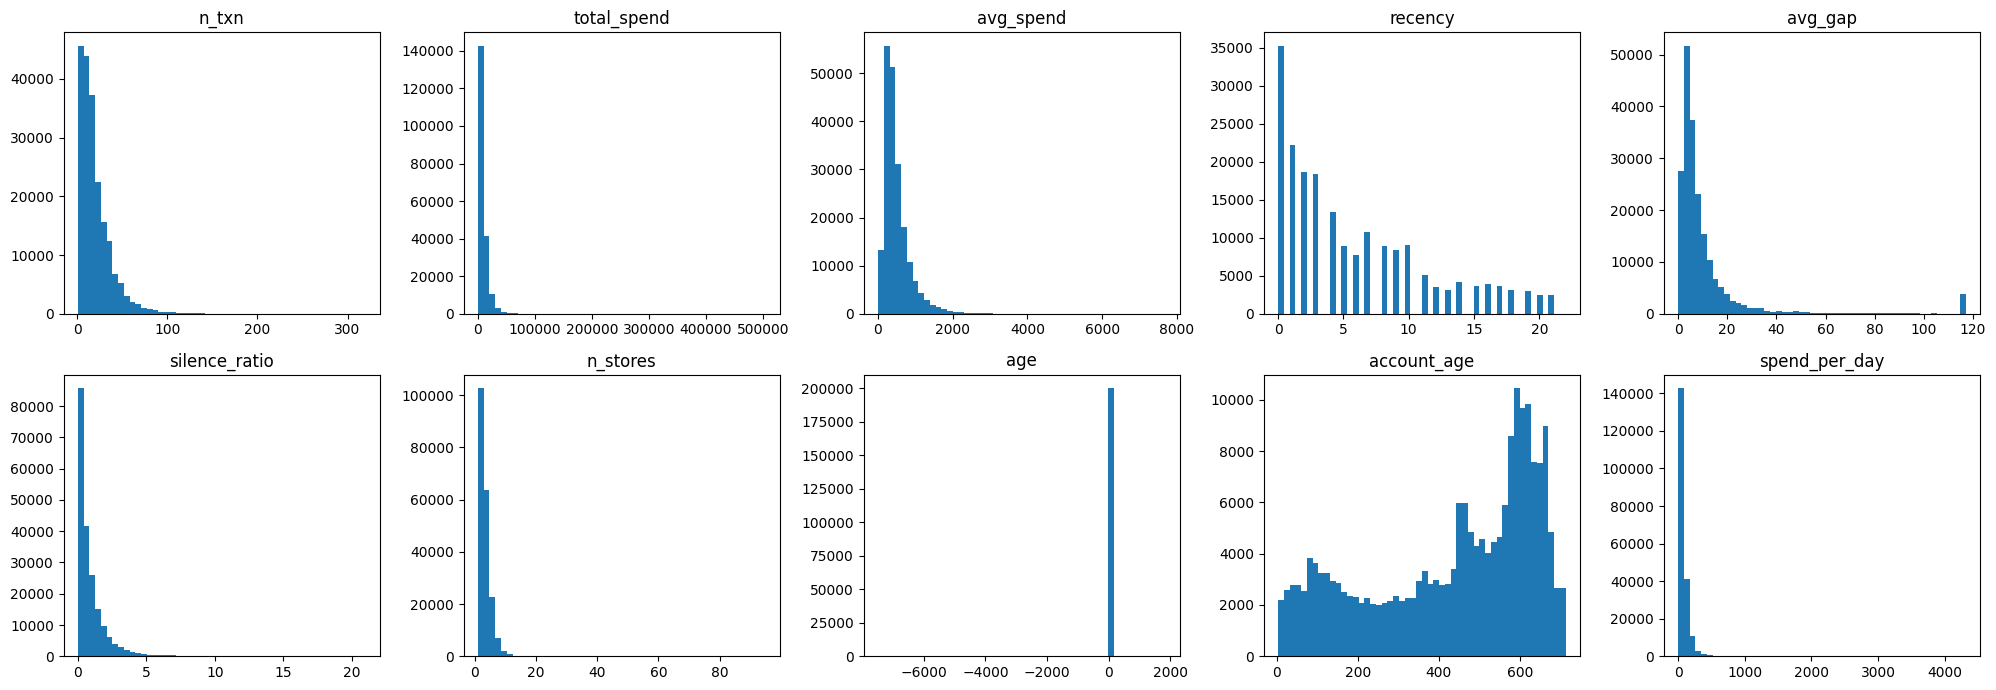

In [31]:
import matplotlib.pyplot as plt

cols = ['n_txn','total_spend','avg_spend','recency','avg_gap',
        'silence_ratio','n_stores','age','account_age','spend_per_day']

fig, axes = plt.subplots(2, 5, figsize=(20, 7))
for ax, c in zip(axes.ravel(), cols):
    ax.hist(df[c].dropna(), bins=50)
    ax.set_title(c)
plt.tight_layout()
plt.savefig(f'{PROJECT}/figures/feature_distributions.png', dpi=120)
plt.show()

**Observations**

* `age` contains impossible values, reaching below −6,000. These are data errors
  rather than outliers and must be handled before modelling. The spike at a
  single value suggests a placeholder was used for missing ages.
* `recency` is bounded at roughly 21 days, far short of the 117-day window. This
  means every customer in the campaign had shopped recently, which is a
  selection property of the experiment rather than of the data. Customers were
  presumably chosen for the campaign from among the recently active.
* This materially changes the retention framing. The dataset does not contain
  long-lapsed customers, so the model predicts near-term lapse among currently
  active customers, not the recovery of customers who already left. This must be
  stated as a limitation.
* `total_spend`, `avg_spend`, `n_txn`, `spend_per_day` and `n_stores` are all
  heavily right-skewed. A small number of very heavy customers dominates each
  distribution. These require log transformation before clustering, since
  distance-based methods would otherwise place cluster centres near the extremes.
* `silence_ratio` is concentrated below 2 with a thin right tail, consistent
  with most customers being roughly on schedule and a minority overdue.
* `account_age` is left-skewed with a peak near 600 days, showing most loyalty
  cards were issued well before the observation window. This confirms that
  tenure had to come from `first_issue_date` rather than from the transaction
  file.
* `avg_gap` shows a spike at 117, the fill value assigned to single-transaction
  customers. This is expected and is flagged by `gap_reliable`.

In [32]:
print(df['age'].describe())
print('Negative age:', (df['age'] < 0).sum())
print('Age > 100:', (df['age'] > 100).sum())
print('Age < 14:', ((df['age'] >= 0) & (df['age'] < 14)).sum())
print()
print(df['recency'].describe())
print('Recency > 30:', (df['recency'] > 30).sum())

count    200039.000000
mean         46.417329
std          49.532475
min       -7491.000000
25%          34.000000
50%          45.000000
75%          59.000000
max        1852.000000
Name: age, dtype: float64
Negative age: 56
Age > 100: 521
Age < 14: 306

count    200039.000000
mean          5.828853
std           5.668023
min           0.000000
25%           1.000000
50%           4.000000
75%           9.000000
max          22.000000
Name: recency, dtype: float64
Recency > 30: 0


**Observations — age**

* 56 customers have negative ages, down to −7,491, and 521 are recorded as over
  100 with a maximum of 1,852. A further 306 are under 14, which is implausible
  for a loyalty cardholder.
* Together this is 883 records out of 200,039, roughly 0.44%. These are data
  entry or system errors rather than genuine outliers.
* Median age is 45 and the interquartile range runs from 34 to 59, which is a
  plausible grocery shopper profile. The standard deviation of 49.5 is inflated
  entirely by the corrupt values.
* Ages outside a plausible range are set to missing and imputed with the median,
  rather than dropping the customers, since the rest of their behavioural data
  is intact.

**Observations — recency**

* Recency has a maximum of 22 days despite a 117-day observation window. Not one
  campaign customer had been inactive for more than three weeks.
* The median is 4 days and 75% shopped within 9 days. Every customer in this
  experiment was actively shopping when the campaign was sent.
* This is a selection property of the campaign, not of the underlying data. X5
  appears to have targeted the recently active rather than the lapsed.
* This materially changes what the retention layer can claim. The model predicts
  **near-term lapse among currently active customers**, not the reactivation of
  customers who had already stopped. Long-dormant customers are absent from the
  data entirely.
* This also strengthens the case for `silence_ratio` over raw recency. When
  every customer shopped within three weeks, absolute recency separates people
  poorly. Relative to a customer's own rhythm, 14 days of silence is routine for
  a monthly shopper and unusual for a daily one. Whether this holds is tested in
  the feature importance results.

In [33]:
df['age_clean'] = df['age'].where((df['age'] >= 14) & (df['age'] <= 100))
df['age_missing'] = df['age_clean'].isna()
df['age_clean'] = df['age_clean'].fillna(df['age_clean'].median())

print(df['age_clean'].describe())
print('Flagged as invalid:', df['age_missing'].sum())

df.to_parquet(f'{PROJECT}/processed/modelling_table.parquet')

count    200039.000000
mean         46.415019
std          15.840458
min          14.000000
25%          34.000000
50%          45.000000
75%          59.000000
max         100.000000
Name: age_clean, dtype: float64
Flagged as invalid: 883


**Observations**

* After cleaning, age ranges from 14 to 100 with a median of 45. The standard
  deviation falls from 49.5 to 15.8, confirming that the earlier spread was
  driven entirely by the 883 invalid records rather than by genuine variation.
* The quartiles are unchanged at 34 and 59, so cleaning affected only the tails.
  The central distribution was always sound.
* 883 customers (0.44%) are flagged in `age_missing` and imputed with the median.
  They are retained rather than dropped, since their behavioural features are
  intact and only the demographic field was corrupt.
* The flag is kept as a feature. If invalid ages correlate with a particular
  registration channel or account vintage, the model can use that rather than
  treating these customers as ordinary 45-year-olds.

### 3.9 Transforming skewed features

The distributions showed that spend, transaction count and store count are
heavily right-skewed. A small number of very heavy customers sits far from
everyone else.

This matters for clustering specifically. K-means assigns customers to the
nearest centre using straight-line distance, so a feature with a long tail
dominates the calculation. One customer spending ₹500,000 would pull a cluster
centre toward themselves and leave the remaining thousands of customers
squeezed together, indistinguishable.

A log transform compresses the tail while preserving order. The gap between
₹1,000 and ₹2,000 becomes comparable to the gap between ₹100,000 and ₹200,000 —
which reflects how these differences actually matter. Doubling your spend means
the same thing at either scale.

`log1p` is used rather than `log` because it handles zeros, which appear in the
points columns.

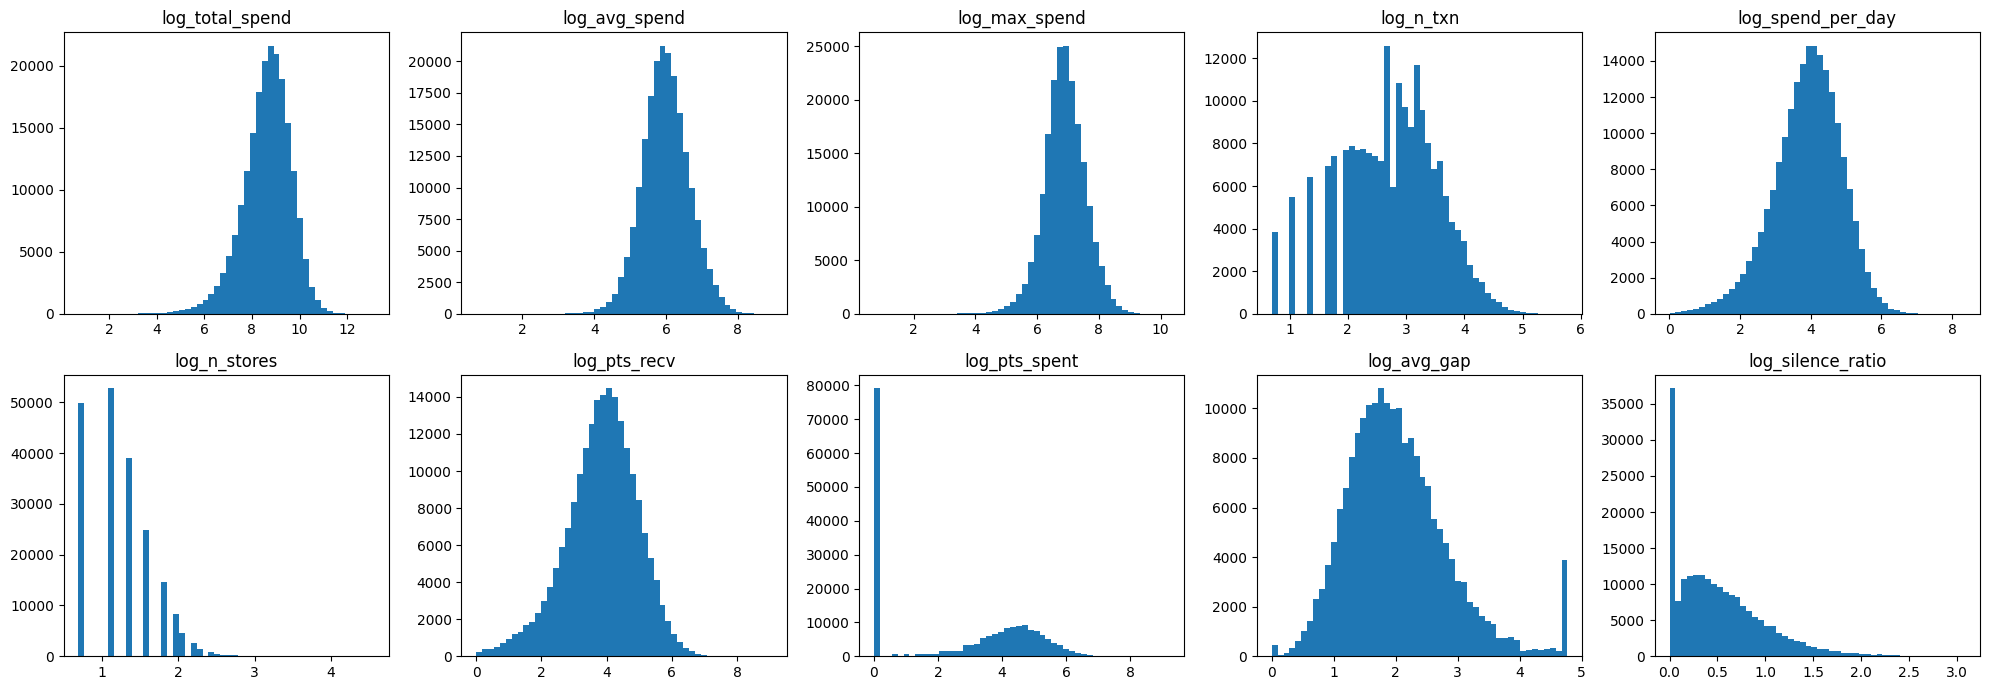

In [34]:
import numpy as np

skewed = ['total_spend','avg_spend','max_spend','n_txn','spend_per_day',
          'n_stores','pts_recv','pts_spent','avg_gap','silence_ratio']

for c in skewed:
    df[f'log_{c}'] = np.log1p(df[c])

fig, axes = plt.subplots(2, 5, figsize=(20, 7))
for ax, c in zip(axes.ravel(), skewed):
    ax.hist(df[f'log_{c}'].dropna(), bins=50)
    ax.set_title(f'log_{c}')
plt.tight_layout()
plt.savefig(f'{PROJECT}/figures/log_distributions.png', dpi=120)
plt.show()

df.to_parquet(f'{PROJECT}/processed/modelling_table.parquet')

**Observations**

* `log_total_spend`, `log_avg_spend`, `log_max_spend`, `log_spend_per_day`,
  `log_pts_recv` and `log_avg_gap` are now close to symmetric. The long right
  tails have gone, so no single heavy customer will dominate distance
  calculations during clustering.
* `log_n_txn` shows a jagged, multi-peaked shape. This is expected — transaction
  count is a small integer, so the log of 8, 9 and 10 are distinct values rather
  than a smooth range. The skew is corrected even though the shape is not
  smooth.
* `log_n_stores` is similarly discrete. Most customers shop at one to three
  stores, so the variable has only a handful of distinct values. It behaves more
  like a category than a continuous measure.
* `log_pts_spent` is bimodal, with a large spike at zero and a separate bump
  around 4 to 6. This reflects the earlier finding that a quarter of customers
  never redeem points at all. The two peaks are two different populations rather
  than one skewed distribution, so a log transform cannot make it symmetric.
  `ever_redeemed` should carry the split and `log_pts_spent` the intensity.
* `log_silence_ratio` retains a spike near zero and a right tail. The spike is
  customers who shopped very recently relative to their own rhythm. The
  transform has compressed the extreme values without erasing the shape that
  matters.
* `log_avg_gap` shows a small spike at the far right, which is the 117-day fill
  value for single-transaction customers. This is expected and flagged by
  `gap_reliable`.
* Six features are now suitable for distance-based clustering. The discrete and
  bimodal ones are noted so their behaviour in the clustering step is not
  mistaken for a fault.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd, numpy as np, os
import matplotlib.pyplot as plt

PROJECT = '/content/drive/MyDrive/Customer-Retention-Segmentation-Uplift'

df = pd.read_parquet(f'{PROJECT}/processed/modelling_table.parquet')
print(df.shape)

Mounted at /content/drive
(200039, 41)


In [3]:
print(df.isna().sum()[df.isna().sum() > 0])
print('\nDuplicate client_id:', df['client_id'].duplicated().sum())
print('Zero/negative spend:', (df['total_spend'] <= 0).sum())
print('\ngender:', df['gender'].value_counts())

days_to_redeem    17546
std_spend          3820
std_gap            9292
max_gap            3820
dtype: int64

Duplicate client_id: 0
Zero/negative spend: 0

gender: gender
U    92832
F    73696
M    33511
Name: count, dtype: int64


**Observations**

* No duplicate customers and no zero or negative spend. The table is one row per
  customer with valid transaction totals.
* Four columns contain nulls, all for structural reasons rather than data
  quality problems:
  * `days_to_redeem` — 17,546 missing, matching the customers who never redeemed
    points. There is no date to subtract from.
  * `std_spend` and `max_gap` — 3,820 missing each. These are the
    single-transaction customers. One purchase gives no spread to measure and no
    gap between visits.
  * `std_gap` — 9,292 missing. This includes customers with one or two
    transactions, since a standard deviation needs at least two gaps and
    therefore three purchases.
* Each null is informative. A missing `days_to_redeem` means the customer never
  engaged with redemption, which is already captured by `has_redeem_date`.
  Missing gap statistics mean too little history to measure rhythm, already
  captured by `gap_reliable`.
* Gender is dominated by `U` at 92,832 customers, 46% of the base. This is not a
  third gender category but unrecorded data. Female outnumbers male roughly two
  to one among those who did record it, which is plausible for grocery retail.
  Since nearly half is unknown, gender is treated as a three-level categorical
  variable rather than being imputed.

In [4]:
df['days_to_redeem'] = df['days_to_redeem'].fillna(-1)
df['std_spend'] = df['std_spend'].fillna(0)
df['std_gap']   = df['std_gap'].fillna(0)
df['max_gap']   = df['max_gap'].fillna(117)

print(df.isna().sum().sum(), 'nulls remaining')
df.to_parquet(f'{PROJECT}/processed/modelling_table.parquet')

0 nulls remaining


### 3.10 EDA Summary

Six findings shape the rest of the project.

**The purchase window is 117 days.** Too short to build a return-rate curve or
a temporal split. The inactivity label therefore comes from the control group's
observed campaign outcome instead of from a chosen silence threshold.

**Randomisation held.** Every pre-campaign feature differs by under 1% between
treated and control. The causal estimate rests on verified balance, not on the
competition's description.

**The naive uplift is 3.32 percentage points.** 60.3% of the control group
purchased anyway. This is the number the targeting model must beat, and the high
base rate is itself the problem — a blanket campaign spends most of its budget
on customers who need nothing.

**No customer was inactive for more than 22 days.** The campaign targeted the
recently active, so the dataset contains no lapsed customers. The retention
model addresses near-term lapse among active customers, not reactivation.

**30% of customers are lapsed redeemers.** They engaged with the loyalty program
historically but not within the window. This is a candidate early warning signal
and its predictive value is tested directly.

**Spend features are heavily skewed and 883 ages are invalid.** Both handled:
log transforms for the skew, median imputation with a flag for the ages.

The working table is 200,039 customers with behavioural, demographic and
campaign columns, saved to `modelling_table.parquet`.

## 4. Data splitting

All model comparison happens on a validation set. The test set is opened once,
at the end, for the selected model only.

Comparing several models on the same held-out data and taking the best means
part of the winner's score is luck rather than skill. Keeping a test set that is
never used for selection is what makes the final number honest.

The split is stratified jointly on `treatment` and `target`, so all four
combinations appear in the same proportion in every partition. This matters for
Layer 3, where Qini compares treated and control customers inside each ranked
slice.

**Selection rule, stated in advance:** models are chosen by validation score.
Where two are within 0.005, the simpler and faster one wins. The test set is
used once.

In [5]:
from sklearn.model_selection import train_test_split

strat = df['treatment'].astype(str) + '_' + df['target'].astype(str)

train, temp = train_test_split(df, test_size=0.30, random_state=42, stratify=strat)
strat_temp  = temp['treatment'].astype(str) + '_' + temp['target'].astype(str)
val, test   = train_test_split(temp, test_size=0.50, random_state=42, stratify=strat_temp)

for name, part in [('train', train), ('val', val), ('test', test)]:
    print(name, part.shape,
          '| treated:', round(part['treatment'].mean(), 4),
          '| target:',  round(part['target'].mean(), 4))

train.to_parquet(f'{PROJECT}/processed/train.parquet')
val.to_parquet(f'{PROJECT}/processed/val.parquet')
test.to_parquet(f'{PROJECT}/processed/test.parquet')

train (140027, 41) | treated: 0.4998 | target: 0.6199
val (30006, 41) | treated: 0.4998 | target: 0.6199
test (30006, 41) | treated: 0.4998 | target: 0.6199


**Observations — split**

* Train 140,027, validation 30,006, test 30,006. All three have a treated share
  of 0.4998 and a target rate of 0.6199, identical to four decimal places.
* Stratification worked exactly as intended. Any difference in model performance
  across partitions cannot be explained by composition.

## 5. Layer 1 — Customer Segmentation

### 5.1 Baseline: RFM quantile segmentation

RFM is the standard retail approach and uses no machine learning. Recency,
frequency and monetary value are split into quartiles and scored 1 to 4.
Recency is reversed, since shopping recently is good.

This baseline answers a specific question. Behavioural clustering uses many more
features, but recency and spend dominate most retail datasets, so there is a
real risk that clusters simply reproduce a ranking RFM gives for free.

The two are cross-tabulated later. A near-diagonal table means clustering added
nothing. Customers spread across cells means the behavioural features carry
structure RFM misses.

In [6]:
def add_rfm(d):
    d = d.copy()
    d['R'] = pd.qcut(d['recency'].rank(method='first'),     4, labels=[4,3,2,1]).astype(int)
    d['F'] = pd.qcut(d['n_txn'].rank(method='first'),       4, labels=[1,2,3,4]).astype(int)
    d['M'] = pd.qcut(d['total_spend'].rank(method='first'), 4, labels=[1,2,3,4]).astype(int)
    d['RFM_total'] = d[['R','F','M']].sum(axis=1)
    return d

train = add_rfm(train)
val   = add_rfm(val)

train.groupby('RFM_total').agg(
    n=('client_id','count'),
    spend=('total_spend','mean'),
    txns=('n_txn','mean'),
    recency=('recency','mean'),
    target_rate=('target','mean')
).round(2)

,n,spend,txns,recency,target_rate
RFM_total,,,,,
3,12133,1512.24,3.96,14.82,0.27
4,13974,2333.74,5.73,10.33,0.35
5,13549,3566.62,8.52,8.77,0.44
6,14561,4707.34,11.04,7.09,0.52
7,15073,6328.12,14.36,6.00,0.59
8,15255,8026.40,18.19,4.71,0.67
9,15337,10193.44,23.28,3.54,0.73
10,15191,12830.79,29.28,2.21,0.81
11,14146,16228.81,38.35,1.15,0.88


**Observations — RFM baseline**

* The RFM score is strongly related to the outcome. Target rate climbs steadily
  from 27% at score 3 to 94% at score 12, with no reversals.
* This is a strong baseline, and it sets the bar. A behavioural clustering that
  only recovers this ordering has added nothing.
* Every column moves together. Spend rises from ₹1,512 to ₹21,743, transactions
  from 4 to 53, and recency falls from 14.8 days to 0.26. The three RFM
  components are heavily correlated in this dataset, so the combined score is
  close to a single dimension of overall activity.
* This is important for the clustering step. If behavioural clusters also line
  up along one activity axis, they will just be RFM with more steps. The value
  of clustering here depends entirely on whether it can separate customers who
  sit at the same activity level but shop differently — for example a
  single-store weekly shopper versus a multi-store occasional one with the same
  total spend.
* Segment sizes are even, between 10,808 and 15,337 per score. This follows from
  quartile construction and is not evidence of anything.
* Note the target rate here mixes treated and control customers, so it reflects
  both natural behaviour and campaign effect. The retention layer uses control
  customers only.

### 5.2 Feature scaling

K-means assigns customers to the nearest centre by straight-line distance. If
one feature reaches 500,000 and another reaches 20, the first dominates the
calculation entirely and the second is ignored.

All clustering features are therefore standardised to mean 0 and standard
deviation 1. Log-transformed versions are used where available, since the raw
distributions were heavily skewed.

The scaler is fitted on the training set only. Fitting on all the data would
leak information about the held-out rows into the transformation.

In [7]:
from sklearn.preprocessing import StandardScaler

clust_feats = ['log_n_txn','log_total_spend','log_avg_spend','log_spend_per_day',
               'log_n_stores','log_avg_gap','log_silence_ratio','log_pts_recv',
               'redeem_rate','avg_items','age_clean','account_age']

scaler = StandardScaler().fit(train[clust_feats])
X_train_c = scaler.transform(train[clust_feats])
X_val_c   = scaler.transform(val[clust_feats])

print(X_train_c.shape, X_val_c.shape)

(140027, 12) (30006, 12)


### 5.3 Comparing clustering algorithms and choosing k

Two decisions have to be made: which algorithm, and how many groups. Neither
has a correct answer that can be looked up, because clustering has no ground
truth. Both are therefore chosen by comparison rather than assumed.

**Why two algorithms.** K-means assigns every customer to exactly one group and
assumes clusters are roughly round and similar in size. Gaussian Mixture assigns
probabilities instead of hard labels and allows stretched, uneven groups. Real
customers often sit between segments, so soft assignment may fit better. Running
both shows whether that flexibility helps here or not.

**Why k from 2 to 10.** Too few groups and everyone is lumped together. Too many
and the segments become too small for a retention team to act on. The range is
swept and the trade-off inspected rather than a number being picked in advance.

**Why four measures rather than one.**

*Silhouette* measures how well separated the groups are, from −1 to 1. Higher is
better.

*Davies-Bouldin* measures how much the groups overlap. Lower is better. Included
because two measures disagreeing is itself informative.

*Inertia* and *BIC* are the internal fit measures for K-means and GMM
respectively, used to look for an elbow.

*min_pct* is the share of customers in the smallest group. This is the one most
people omit, and it is the reason many published segmentations are unusable. A
clustering can score well on silhouette while producing one enormous group and
several containing 2% of customers. A segment that small cannot support a
campaign.

**Why a 20,000-row sample for scoring.** Silhouette compares every point against
every other, so its cost grows with the square of the dataset size. On 140,027
customers it would take hours. The models are fitted on the full training set
and only scored on a fixed random sample, so the comparison stays fair across
all k.

**Selection rule.** The chosen configuration must balance separation, segment
size and interpretability. The highest silhouette does not automatically win.

In [8]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score
import numpy as np

rs = np.random.RandomState(42)
sample = rs.choice(len(X_train_c), 20000, replace=False)
Xs = X_train_c[sample]

rows = []

for k in range(2, 11):
    km  = MiniBatchKMeans(n_clusters=k, random_state=42, n_init=10).fit(X_train_c)
    lab = km.predict(Xs)
    rows.append({'algo':'kmeans', 'k':k,
                 'silhouette': silhouette_score(Xs, lab),
                 'davies_bouldin': davies_bouldin_score(Xs, lab),
                 'inertia': km.inertia_,
                 'min_pct': 100*pd.Series(km.labels_).value_counts(normalize=True).min()})

for k in range(2, 11):
    gm  = GaussianMixture(n_components=k, random_state=42).fit(Xs)
    lab = gm.predict(Xs)
    rows.append({'algo':'gmm', 'k':k,
                 'silhouette': silhouette_score(Xs, lab),
                 'davies_bouldin': davies_bouldin_score(Xs, lab),
                 'bic': gm.bic(Xs),
                 'min_pct': 100*pd.Series(lab).value_counts(normalize=True).min()})

comparison = pd.DataFrame(rows)
comparison.round(4)

,algo,k,silhouette,davies_bouldin,inertia,min_pct,bic
0,kmeans,2,0.2160,1.6790,1.291187e+06,38.4126,NaN
1,kmeans,3,0.1409,1.9171,1.153933e+06,28.4916,NaN
2,kmeans,4,0.1292,1.9290,1.074613e+06,17.5673,NaN
3,kmeans,5,0.1252,1.8882,9.958445e+05,10.8158,NaN
4,kmeans,6,0.1078,1.9825,9.598137e+05,11.1557,NaN
5,kmeans,7,0.1074,1.8415,9.154052e+05,10.0931,NaN
6,kmeans,8,0.1034,1.9240,8.845621e+05,4.2056,NaN
7,kmeans,9,0.1062,1.8328,8.551412e+05,7.1686,NaN
8,kmeans,10,0.1133,1.7774,8.089567e+05,2.9901,NaN
9,gmm,2,0.2105,1.9633,NaN,29.7500,179485.6710


**Observations**

* Silhouette scores are low throughout. The best is 0.216 at k=2 for K-means,
  and everything else sits between 0.03 and 0.14. Values below roughly 0.25
  indicate weak separation.
* This means the customers do not form naturally distinct groups. They occupy a
  continuous space, mostly along a single axis of overall activity, rather than
  sitting in separable clusters. This is common in retail and consistent with
  the RFM table, where every component moved together.
* Silhouette falls sharply from k=2 to k=3 and stays flat. There is no elbow and
  no obvious natural k, which is what a continuum looks like.
* K-means outperforms GMM at every k. GMM's Davies-Bouldin worsens steadily from
  1.96 to 3.9, meaning its components overlap increasingly. Soft assignment does
  not help when there is no underlying separation to find.
* GMM's BIC keeps falling as k rises, which would suggest ever more components.
  This is BIC rewarding flexibility on data with no cluster structure, not
  evidence of ten real groups.
* `min_pct` degrades quickly. By k=8 the smallest K-means cluster holds 4.2% of
  customers, and by k=10 just 3.0%. GMM is worse, reaching 2.2%. Segments this
  small are not actionable for a retention team.
* **k=2 scores highest but is not useful.** Two groups of high and low activity
  restate the RFM baseline exactly and give a retention team nothing to act on.
* **k=5 is selected.** Silhouette at 0.125 is within 0.016 of k=3 and k=4, the
  smallest segment holds 10.8% of customers, and five groups is enough to
  describe distinct shopping styles while remaining nameable. Selection follows
  the stated rule: separation, size balance and interpretability together, not
  separation alone.
* The weak separation is reported rather than hidden. It sets an honest
  expectation for the segmentation's value and makes the cross-tabulation
  against RFM the decisive test — if the clusters merely reproduce RFM, the
  layer contributes little.

### 5.4 Fitting the chosen model and profiling the segments

Five clusters are fitted on the full training set using standard K-means rather
than the mini-batch version used for the sweep. Mini-batch trades a little
accuracy for speed, which was the right choice when fitting eighteen models but
not for the one that will actually be used.

The same fitted model is applied to the validation set with `predict`. The
clusters are not refitted there. Refitting would produce different groups with
different meanings, and segment 2 in training would not correspond to segment 2
in validation.

**Why profiling matters more than the fit.** A clustering algorithm returns
numbers, not segments. Segment 0 means nothing until we can say what kind of
customer it contains. The profile table computes the average of every behavioural
feature within each cluster so the groups can be described in plain language.

This is where the interpretability constraint from section 1.4 is satisfied.
The output goes to a retention team, and "target customers in cluster 3" is not
an instruction anyone can act on. "Target frequent single-store shoppers whose
visits are becoming less regular" is.

The features chosen for the profile span all three groups built earlier:

* **Volume** — transaction count, total spend, average basket
* **Rhythm** — average gap between visits, days since last visit
* **Engagement** — number of stores used, items per basket, redemption rate
* **Context** — age, and the campaign outcome rate

`target_rate` is included to show immediately whether the segments differ in
outcome. If every segment has a similar rate, the segmentation carries no
retention signal and the layer contributes little. This is checked here rather
than assumed.

In [9]:
from sklearn.cluster import KMeans

km5 = KMeans(n_clusters=5, random_state=42, n_init=10).fit(X_train_c)
train['segment'] = km5.labels_
val['segment']   = km5.predict(X_val_c)

profile = train.groupby('segment').agg(
    n=('client_id','count'),
    pct=('client_id', lambda s: round(100*len(s)/len(train),1)),
    txns=('n_txn','mean'),
    spend=('total_spend','mean'),
    basket=('avg_spend','mean'),
    gap=('avg_gap','mean'),
    recency=('recency','mean'),
    stores=('n_stores','mean'),
    items=('avg_items','mean'),
    redeem=('redeem_rate','mean'),
    age=('age_clean','mean'),
    target_rate=('target','mean')
).round(2)

profile

,n,pct,txns,spend,basket,gap,recency,stores,items,redeem,age,target_rate
segment,,,,,,,,,,,,
0,40766,29.1,37.28,12512.97,369.57,3.16,3.05,3.99,5.17,0.06,45.43,0.82
1,28555,20.4,7.72,4809.17,695.98,15.99,7.68,2.18,8.59,0.09,44.27,0.43
2,36205,25.9,16.99,4100.84,270.12,6.21,6.44,2.70,4.02,0.05,50.80,0.63
3,18632,13.3,21.09,20841.47,1060.31,6.04,4.53,3.10,11.61,0.10,44.91,0.70
4,15869,11.3,4.21,1087.64,312.49,38.22,9.72,1.77,4.46,0.09,44.38,0.31


**Observations — segment profiles**

Five distinguishable groups emerge, and they are nameable:

**Segment 0 — Frequent small-basket shoppers (29.1%).** 37 trips in 117 days,
roughly one every three days, with a small ₹370 basket. Highest target rate at
82%. These are habitual top-up shoppers.

**Segment 1 — Occasional large-basket shoppers (20.4%).** Only 8 trips but a
₹696 basket, visiting every 16 days. Uses the most stores relative to trip
count. Target rate 43%.

**Segment 2 — Older regular shoppers (25.9%).** Average age 50.8, well above
every other segment. 17 trips with a small ₹270 basket and few items. Target
rate 63%.

**Segment 3 — High-value bulk shoppers (13.3%).** Highest spend by far at
₹20,841, with a ₹1,060 basket and 11.6 items per trip. Highest redemption rate.
Target rate 70%.

**Segment 4 — Lapsing light shoppers (11.3%).** Only 4 trips, ₹1,088 total
spend, 38 days between visits and 9.7 days since the last one. Lowest target
rate at 31%. This is the at-risk group.

Target rate ranges from 31% to 82% across segments, so the segmentation carries
real retention signal rather than dividing customers arbitrarily.

In [10]:
pd.crosstab(train['segment'], train['RFM_total'], normalize='index').round(3)*100

RFM_total,3,4,5,6,7,8,9,10,11,12
segment,,,,,,,,,,
0,0.0,0.0,0.2,1.2,4.9,9.9,15.8,21.6,24.7,21.7
1,11.2,19.4,20.0,19.8,14.7,9.6,4.5,0.9,0.0,0.0
2,4.4,9.4,15.4,17.6,18.4,15.8,11.7,6.0,1.4,0.0
3,0.0,0.0,1.1,4.8,10.2,14.7,18.1,21.3,19.3,10.5
4,46.4,31.6,12.7,7.5,1.8,0.0,0.0,0.0,0.0,0.0


**Observations — cross-tabulation against RFM**

This is the decisive test, and the clusters pass it.

* Segments 0 and 3 occupy almost identical RFM territory. Both concentrate at
  scores 9 to 12, with segment 0 at 84% and segment 3 at 69% in that range. RFM
  would treat them as the same kind of valuable customer.
* They are behaviourally opposite. Segment 0 makes 37 trips with a ₹370 basket.
  Segment 3 makes 21 trips with a ₹1,060 basket. One shops constantly and buys
  little; the other shops half as often and fills a trolley.
* Their target rates differ by 12 points, 82% against 70%, so the distinction
  has consequences for the outcome as well as for behaviour.
* Segment 4 is the mirror case, concentrated at RFM 3 and 4 with 78% of its
  customers there. Here clustering and RFM agree, which is expected — low
  activity is low activity however it is measured.
* Segments 1 and 2 both spread widely across the middle of the RFM range,
  overlapping heavily in score but differing in age, basket size and store
  count. RFM cannot separate them; the behavioural features can.
* The table is therefore not diagonal. Clustering has recovered structure that
  RFM misses, specifically among high-value customers, where the distinction
  between frequent-small and infrequent-large matters most for choosing an
  intervention.
* This justifies the segmentation layer despite the low silhouette scores. The
  groups are not cleanly separated in space, but they are behaviourally and
  operationally distinct, which is what the retention team needs.

In [11]:
train.to_parquet(f'{PROJECT}/processed/train.parquet')
val.to_parquet(f'{PROJECT}/processed/val.parquet')

In [12]:
import joblib
joblib.dump(km5, f'{PROJECT}/models/kmeans_k5.pkl')
joblib.dump(scaler, f'{PROJECT}/models/scaler_clustering.pkl')

['/content/drive/MyDrive/Customer-Retention-Segmentation-Uplift/models/scaler_clustering.pkl']

## 6. Layer 2 — Retention

### 6.1 Constructing the label

The retention label comes from the control group only.

Of the 140,027 training customers, roughly half received no message. For those
customers, `target = 0` records that they did not purchase in the period
following the campaign, having received nothing. That is an observed
non-return, not an inferred one.

The label is inverted so that 1 marks the event of interest:

    not_returned = 1 - target

Treated customers are excluded from this layer. Their outcome reflects both
their natural behaviour and the effect of the message, so a model trained on
them would learn who responds to an SMS rather than who lapses on their own. A
retention model should predict what happens when nothing is done.

This halves the available data, from 140,027 to around 70,000. That cost is
accepted, because a model trained on a contaminated outcome would answer the
wrong question.

In [13]:
ctrl_train = train[train['treatment'] == 0].copy()
ctrl_val   = val[val['treatment'] == 0].copy()

ctrl_train['not_returned'] = 1 - ctrl_train['target']
ctrl_val['not_returned']   = 1 - ctrl_val['target']

print('train:', ctrl_train.shape, 'rate:', round(ctrl_train['not_returned'].mean(), 4))
print('val:  ', ctrl_val.shape,   'rate:', round(ctrl_val['not_returned'].mean(), 4))
print()
print(ctrl_train.groupby('segment')['not_returned'].agg(['mean','count']).round(3))

train: (70041, 47) rate: 0.3967
val:   (15008, 47) rate: 0.3967

          mean  count
segment              
0        0.183  20358
1        0.584  14417
2        0.391  18060
3        0.308   9190
4        0.717   8016


**Observations — label**

* 39.67% of control customers did not return, identical in train and validation.
  This is a well-balanced binary problem, not an imbalanced one. The earlier
  concern about accuracy being invalid applies less here than expected, though
  PR-AUC remains the primary metric since ranking is what matters.
* Non-return rate varies enormously by segment, from 18.3% in segment 0 to
  71.7% in segment 4. A frequent small-basket shopper is four times more likely
  to return than a lapsing light shopper.
* This is the segmentation layer paying off. The clusters were built without
  any reference to the outcome, yet they separate it strongly.
* Note segments 0 and 3, which RFM treated as equivalent, differ by 12.5 points
  in non-return rate. The behavioural distinction has retention consequences.

### 6.2 Baseline: recency rule

Before any model, a rule that uses no machine learning at all. Customers are
ranked by how many days have passed since their last purchase, longest first.

This is what a retention team would do with a spreadsheet, and it is the bar
every model must clear. A gradient boosting model that beats a sorted column by
0.01 PR-AUC has not earned its complexity.

Recency is used as a continuous score rather than a threshold, so it can be
compared on the same ranking metrics as the models.

In [14]:
from sklearn.metrics import average_precision_score, roc_auc_score

def prec_rec_at_k(y_true, scores, k):
    idx = np.argsort(-scores)[:k]
    hits = y_true.iloc[idx].sum() if hasattr(y_true, 'iloc') else y_true[idx].sum()
    return hits/k, hits/y_true.sum()

results = []

def log_result(name, y_true, scores, seconds=0):
    p5k, r5k = prec_rec_at_k(y_true.reset_index(drop=True), np.asarray(scores), 5000)
    results.append({
        'model': name,
        'pr_auc': average_precision_score(y_true, scores),
        'roc_auc': roc_auc_score(y_true, scores),
        'prec@5k': p5k,
        'rec@5k': r5k,
        'seconds': round(seconds, 1),
    })
    return pd.DataFrame(results).sort_values('pr_auc', ascending=False).round(4)

log_result('baseline: recency', ctrl_val['not_returned'], ctrl_val['recency'].values)

,model,pr_auc,roc_auc,prec@5k,rec@5k,seconds
0,baseline: recency,0.572,0.7029,0.6042,0.5074,0


In [15]:
log_result('baseline: silence_ratio', ctrl_val['not_returned'],
           ctrl_val['silence_ratio'].values)

,model,pr_auc,roc_auc,prec@5k,rec@5k,seconds
0,baseline: recency,0.5720,0.7029,0.6042,0.5074,0
1,baseline: silence_ratio,0.4384,0.5565,0.4212,0.3537,0


**Observations — baselines**

* Ranking by recency alone achieves PR-AUC 0.572 against a base rate of 0.397.
  This is a strong baseline. Sorting one column already identifies non-returners
  substantially better than chance, and any model must clearly beat it.
* Precision at the top 5,000 is 60.4%, so three in five customers flagged by
  recency alone genuinely did not return.
* `silence_ratio` performs far worse, at PR-AUC 0.438 and ROC-AUC 0.557, barely
  above random.
* This contradicts the original hypothesis, and the reason is visible in the
  EDA. Recency in this dataset never exceeds 22 days, because the campaign
  targeted only recently active customers. Dividing a narrow recency range by a
  widely varying `avg_gap` mostly amplifies noise in the denominator. A customer
  with an unstable purchase rhythm gets an extreme ratio for reasons unrelated
  to their risk of lapsing.
* The idea that inactivity should be measured relative to personal rhythm is
  sound in general. It fails here specifically because the recency range is too
  compressed for the adjustment to add information.
* `silence_ratio` is retained as a model feature rather than discarded. A
  gradient boosting model can use it conditionally, alongside `gap_reliable` and
  `n_txn`, in a way a bare ranking cannot. Its final feature importance will
  show whether it contributes anything at all.

### 6.3 Building the feature matrix

Before comparing models, the input columns must be chosen deliberately rather
than by passing everything available. Several columns in the table would either
break the model or invalidate the result.

**What is excluded, and why.**

`target` and `not_returned` are the outcome itself. Including either would give
the model the answer and produce a perfect score that means nothing.

`treatment` is constant here, since this layer uses control customers only. A
column with no variation contributes nothing.

`client_id` is an identifier. It carries no behavioural meaning, and a
tree-based model can memorise it, which is a subtle form of overfitting.

`segment` is excluded on purpose. The cluster label is derived from the same
behavioural features already in the matrix, so it adds no new information while
making feature importance harder to read. It is used later to analyse results by
group rather than as an input.

`R`, `F`, `M` and `RFM_total` are excluded for the same reason. They are
quantile transforms of recency, transaction count and spend, all of which are
already present in their raw and logged forms.

`gender` is excluded here because it is text and would need encoding. It is a
candidate for a later iteration, though with 46% of values recorded as unknown
its value is limited.

**One caution about the remaining features.** Several appear in both raw and
log-transformed form — `total_spend` and `log_total_spend`, for example. This is
harmless for tree-based models, which are invariant to monotonic transformations
and will simply pick whichever splits better. It would matter for a linear
model, where correlated inputs distort coefficients. This is noted where
logistic regression is compared.

The column list is printed and inspected rather than trusted. Leakage is easiest
to catch by reading the names.

In [16]:
drop = ['client_id','treatment','target','not_returned','segment',
        'R','F','M','RFM_total','gender']

feat_cols = [c for c in ctrl_train.columns
             if c not in drop and ctrl_train[c].dtype != 'object']

X_tr = ctrl_train[feat_cols].astype(float)
y_tr = ctrl_train['not_returned']
X_va = ctrl_val[feat_cols].astype(float)
y_va = ctrl_val['not_returned']

print(X_tr.shape, len(feat_cols))
print(feat_cols)

(70041, 37) 37
['age', 'account_age', 'has_redeem_date', 'days_to_redeem', 'n_txn', 'total_spend', 'avg_spend', 'max_spend', 'std_spend', 'avg_items', 'avg_qty', 'n_stores', 'avg_gap', 'std_gap', 'max_gap', 'pts_recv', 'pts_spent', 'n_redeemed', 'recency', 'silence_ratio', 'gap_reliable', 'spend_per_day', 'ever_redeemed', 'redeem_rate', 'lapsed_redeemer', 'age_clean', 'age_missing', 'log_total_spend', 'log_avg_spend', 'log_max_spend', 'log_n_txn', 'log_spend_per_day', 'log_n_stores', 'log_pts_recv', 'log_pts_spent', 'log_avg_gap', 'log_silence_ratio']


In [17]:
feat_cols = [c for c in feat_cols if c != 'age']
X_tr = ctrl_train[feat_cols].astype(float)
X_va = ctrl_val[feat_cols].astype(float)
print(X_tr.shape)

(70041, 36)


### 6.4 Comparing retention models

Seven models across four families are compared, rather than assuming a gradient
boosting model is correct. Each trains on the same features and is scored on the
same validation set.

**Recency rule** — already run. No machine learning at all, and the bar every
model must clear.

**Linear**

*Logistic Regression* — included to establish whether the relationship is
mostly linear. If it matches the tree models, the added complexity is not buying
anything. Fitted on scaled features, since the matrix contains raw and
log-transformed versions of the same columns, which distorts linear coefficients.

**Single tree**

*Decision Tree* — depth-limited to stay interpretable. Shows how much of the
signal is available from a handful of splits, and gives a sense of how much the
ensembles are adding.

**Bagged trees**

*Random Forest* — many deep trees on bootstrapped samples, averaged. Robust and
hard to overfit.

*Extra Trees* — the same idea with randomly chosen split points rather than
optimal ones. Faster, and occasionally better when the optimal splits are fitting
noise.

**Boosted trees**

*XGBoost*, *LightGBM* and *CatBoost* — the three standard implementations.
Usually strongest on tabular problems. All three are included because they grow
trees differently: XGBoost level-wise, LightGBM leaf-wise, CatBoost with ordered
boosting. These differences occasionally produce a meaningful gap on the same
data.

**What was excluded, and why**

SVM, KNN and neural approaches were left out deliberately rather than run. On
70,000 rows and 36 features, kernel methods scale poorly with sample size,
distance-based methods degrade in this many dimensions, and gradient boosting is
the established strong performer on tabular data of this shape. Comparison was
scoped to families that could plausibly win.

**Selection rule, as stated in section 4:** highest validation PR-AUC, with the
simpler and faster model preferred where two are within 0.005. Training time is
recorded, because a model gaining 0.002 PR-AUC for ten times the runtime is not
the better choice.

In [19]:
!pip install xgboost lightgbm catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 27.7 MB/s eta 0:00:00


In [20]:
import time
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

models = {
    # --- linear ---
    'logistic': make_pipeline(StandardScaler(),
                  LogisticRegression(max_iter=2000, random_state=42)),

    # --- single tree ---
    'decision_tree': DecisionTreeClassifier(max_depth=6, random_state=42),

    # --- bagged trees ---
    'random_forest': RandomForestClassifier(n_estimators=300, max_depth=12,
                       n_jobs=-1, random_state=42),
    'extra_trees': ExtraTreesClassifier(n_estimators=300, max_depth=12,
                     n_jobs=-1, random_state=42),

    # --- boosted trees ---
    'xgboost': xgb.XGBClassifier(n_estimators=400, max_depth=6,
                 learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
                 eval_metric='logloss', n_jobs=-1, random_state=42),
    'lightgbm': lgb.LGBMClassifier(n_estimators=400, learning_rate=0.05,
                  num_leaves=31, subsample=0.8, colsample_bytree=0.8,
                  n_jobs=-1, random_state=42, verbose=-1),
    'catboost': CatBoostClassifier(iterations=400, depth=6, learning_rate=0.05,
                  random_state=42, verbose=0),
}

fitted = {}
for name, m in models.items():
    t0 = time.time()
    m.fit(X_tr, y_tr)
    secs = time.time() - t0
    fitted[name] = m
    log_result(name, y_va, m.predict_proba(X_va)[:, 1], secs)
    print(f'{name:<15} done in {secs:.1f}s')

comparison_l2 = pd.DataFrame(results).sort_values('pr_auc', ascending=False).round(4)
comparison_l2

logistic        done in 1.1s
decision_tree   done in 1.3s
random_forest   done in 11.0s
extra_trees     done in 2.1s
xgboost         done in 9.5s
lightgbm        done in 5.5s
catboost        done in 3.0s


,model,pr_auc,roc_auc,prec@5k,rec@5k,seconds
13,catboost,0.6779,0.7824,0.6688,0.5616,3.0
10,extra_trees,0.6744,0.7802,0.6662,0.5595,2.1
12,lightgbm,0.6739,0.7802,0.6664,0.5596,5.5
6,lightgbm,0.6739,0.7802,0.6664,0.5596,1.2
2,logistic,0.6727,0.7798,0.6656,0.5590,1.0
7,logistic,0.6727,0.7798,0.6656,0.5590,1.1
4,random_forest,0.6727,0.7805,0.6642,0.5578,11.1
9,random_forest,0.6727,0.7805,0.6642,0.5578,11.0
11,xgboost,0.6726,0.7792,0.6610,0.5551,9.5
5,xgboost,0.6726,0.7792,0.6610,0.5551,1.9


In [21]:
comparison_l2 = (pd.DataFrame(results)
                 .drop_duplicates(subset='model', keep='last')
                 .sort_values('pr_auc', ascending=False)
                 .round(4))
comparison_l2

,model,pr_auc,roc_auc,prec@5k,rec@5k,seconds
13,catboost,0.6779,0.7824,0.6688,0.5616,3.0
10,extra_trees,0.6744,0.7802,0.6662,0.5595,2.1
12,lightgbm,0.6739,0.7802,0.6664,0.5596,5.5
7,logistic,0.6727,0.7798,0.6656,0.5590,1.1
9,random_forest,0.6727,0.7805,0.6642,0.5578,11.0
11,xgboost,0.6726,0.7792,0.6610,0.5551,9.5
8,decision_tree,0.6559,0.7736,0.6580,0.5526,1.3
0,baseline: recency,0.5720,0.7029,0.6042,0.5074,0.0
1,baseline: silence_ratio,0.4384,0.5565,0.4212,0.3537,0.0


**Observations**

* Every model beats the recency baseline clearly. PR-AUC rises from 0.572 to
  around 0.674, so the behavioural features add real information beyond sorting
  by days since last visit.
* CatBoost leads at 0.6779, but the spread across the top six models is
  remarkably narrow. Extra Trees, LightGBM, logistic regression, random forest
  and XGBoost all sit between 0.6726 and 0.6744 — a range of 0.002.
* **Logistic regression reaches 0.6727, within 0.005 of the winner and within
  0.002 of every tree ensemble.** A linear model matching seven-hundred-tree
  boosting ensembles means the relationship between these features and
  non-return is close to linear. The complexity of the ensembles is not buying
  additional signal.
* The selection rule stated in section 4 therefore applies directly: where two
  models are within 0.005, the simpler and faster one is preferred. On that
  rule, **logistic regression is the selected model**, at 1.0 seconds against
  CatBoost's 3.0 and random forest's 11.0.
* CatBoost is retained as the performance reference and both are carried to the
  test set, so the cost of choosing simplicity can be reported rather than
  assumed.
* Random forest is the clear loser on efficiency, taking 11 seconds to match
  logistic regression's score.
* The single decision tree reaches 0.6559, below every ensemble but well above
  the baseline. Most of the signal is available from a few splits, which is
  consistent with the near-linear structure the logistic result suggests.
* Precision at the top 5,000 ranges only from 0.658 to 0.669 across the models,
  against 0.604 for the recency rule. In operational terms, the choice of model
  changes which customers are contacted far less than the choice to use a model
  at all.

### 6.5 Feature importance

Interpretability was listed as a constraint in section 1.4, because the output
goes to a retention team rather than an automated system. A ranked list of
at-risk customers is only actionable if the reason behind the ranking can be
explained.

Feature importance is computed from CatBoost, the highest-scoring model. Note
that importance is read here for explanation, not for feature selection — with
seven models scoring within 0.002 of each other, dropping features on the basis
of one model's ranking would be reading too much into noise.

**This section also tests a specific hypothesis stated earlier.**

`silence_ratio` — recency divided by each customer's own average gap — was
introduced on the argument that inactivity means different things for different
shopping rhythms. Thirty days of silence is alarming for a weekly shopper and
routine for a monthly one. Ranking by it alone already performed poorly, at
PR-AUC 0.438 against recency's 0.572.

Its rank here answers whether the idea contributes anything once a model can
use it conditionally, alongside `gap_reliable` and `n_txn`, rather than as a
standalone score. A bare ranking cannot know when to distrust the ratio; a
tree-based model can.

The ranks of `silence_ratio` and `recency` are printed explicitly so the
comparison is direct rather than eyeballed from a chart.

A caution on reading the chart: several features appear in both raw and
logged form. Tree models split on whichever version happens to work marginally
better, so importance is divided arbitrarily between the pair. Two related
features each ranking mid-table may together matter more than a single feature
ranking above them.

recency              14.881
std_gap              10.127
log_n_txn             7.434
avg_gap               6.397
n_txn                 6.252
log_avg_gap           6.148
account_age           4.723
max_gap               3.765
days_to_redeem        3.395
log_silence_ratio     3.225
age_clean             3.114
silence_ratio         2.708
avg_items             2.690
std_spend             2.481
redeem_rate           2.345
dtype: float64

silence_ratio rank: 12 of 36
recency rank: 1


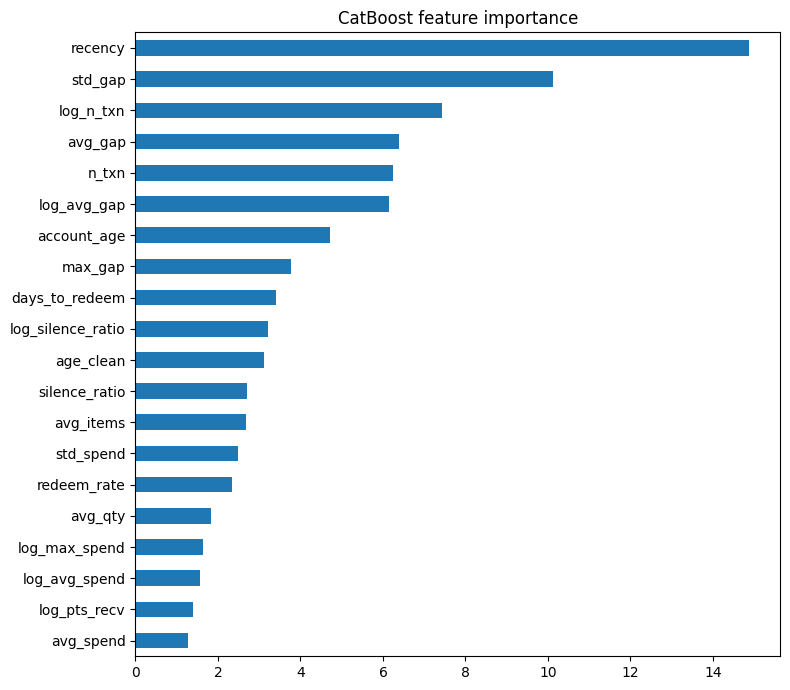

In [23]:
import matplotlib.pyplot as plt

imp = pd.Series(fitted['catboost'].feature_importances_,
                index=X_tr.columns).sort_values(ascending=False)

print(imp.head(15).round(3))
print('\nsilence_ratio rank:', list(imp.index).index('silence_ratio') + 1, 'of', len(imp))
print('recency rank:', list(imp.index).index('recency') + 1)

imp.head(20).plot.barh(figsize=(8,7)).invert_yaxis()
plt.title('CatBoost feature importance')
plt.tight_layout()
plt.savefig(f'{PROJECT}/figures/l2_feature_importance.png', dpi=120)
plt.show()

In [24]:
lr = fitted['logistic'].named_steps['logisticregression']
coef = pd.Series(lr.coef_[0], index=X_tr.columns)

compare_imp = pd.DataFrame({
    'catboost': imp,
    'logistic_abs_coef': coef.abs()
})
compare_imp['cb_rank'] = compare_imp['catboost'].rank(ascending=False)
compare_imp['lr_rank'] = compare_imp['logistic_abs_coef'].rank(ascending=False)
compare_imp.sort_values('catboost', ascending=False).head(15).round(3)

,catboost,logistic_abs_coef,cb_rank,lr_rank
recency,14.881,0.037,1.0,22.0
std_gap,10.127,0.062,2.0,19.0
log_n_txn,7.434,0.208,3.0,5.0
avg_gap,6.397,0.392,4.0,2.0
n_txn,6.252,0.166,5.0,6.0
log_avg_gap,6.148,0.951,6.0,1.0
account_age,4.723,0.015,7.0,30.0
max_gap,3.765,0.112,8.0,7.0
days_to_redeem,3.395,0.020,9.0,26.0
log_silence_ratio,3.225,0.210,10.0,4.0


**Observations**

* The two models score within 0.005 of each other but rank features very
  differently. They reach the same performance through different signals.

* **`silence_ratio` ranks 3rd in logistic regression and 12th in CatBoost.**
  `recency` shows the mirror pattern — 1st in CatBoost, 22nd in logistic.
  The tree model's most important feature is nearly irrelevant to the linear one.

* The reason is what each model can do internally. Trees split on `recency`,
  then split on `avg_gap` within that branch, constructing the relationship
  themselves. A linear model cannot form interactions, so the pre-computed ratio
  does work it could not otherwise do.

* This partially rescues the original hypothesis. Measuring inactivity relative
  to personal rhythm does hold — and since logistic regression is the selected
  model, `silence_ratio` is among its strongest inputs, despite appearing weak
  under CatBoost.

* **The general lesson:** feature importance is a property of the feature and
  the model together, not of the feature alone. Reading importance from one
  model would have suggested dropping a feature the deployed model relies on.

### 6.6 Test set evaluation

The test set has not been touched. It was set aside before any model was fitted
and has played no part in feature selection, model comparison or hyperparameter
choice.

Both models are refitted on train and validation combined. Validation is no
longer needed for selection, so folding it back in gives roughly 20% more
training data. This is standard practice once the choice is made.

Two models are reported rather than one. Logistic regression was selected under
the stated rule — within 0.005 of the leader and three times faster. CatBoost
scored highest on validation. Reporting both shows the actual cost of choosing
the simpler model, instead of asserting it was negligible.

The gap between each model's validation and test score is also informative. A
large drop would indicate the model was partly fitted to the validation set
through repeated comparison.

In [25]:
ctrl_test = test[test['treatment'] == 0].copy()
ctrl_test['not_returned'] = 1 - ctrl_test['target']
X_te = ctrl_test[feat_cols].astype(float)
y_te = ctrl_test['not_returned']

X_full = pd.concat([X_tr, X_va])
y_full = pd.concat([y_tr, y_va])

print(f'{"model":<12} {"val PR-AUC":>11} {"test PR-AUC":>12} {"test ROC":>10} {"prec@5k":>9}')
for name in ['logistic', 'catboost']:
    m = models[name]
    m.fit(X_full, y_full)
    p = m.predict_proba(X_te)[:, 1]
    val_score = comparison_l2.loc[comparison_l2['model'] == name, 'pr_auc'].values[0]
    p5k, _ = prec_rec_at_k(y_te.reset_index(drop=True), p, 5000)
    print(f'{name:<12} {val_score:>11.4f} {average_precision_score(y_te, p):>12.4f} '
          f'{roc_auc_score(y_te, p):>10.4f} {p5k:>9.4f}')
    ctrl_test[f'risk_{name}'] = p

model         val PR-AUC  test PR-AUC   test ROC   prec@5k
logistic          0.6727       0.6715     0.7756    0.6580
catboost          0.6779       0.6786     0.7775    0.6670


**Observations**

* Test scores are almost identical to validation. Logistic regression: 0.6727
  validation against 0.6715 test. CatBoost: 0.6779 against 0.6786.
* The gaps are under 0.002 in both cases, and CatBoost actually scored slightly
  higher on test. There is no meaningful drop, so comparing nine models on the
  validation set did not overfit the selection.
* **The cost of choosing the simpler model is 0.0071 PR-AUC** — 0.6715 against
  0.6786. In precision terms, of 5,000 customers contacted, CatBoost identifies
  roughly 45 more genuine non-returners than logistic regression.
* Whether that trade is worth making depends on the cost per contact. At a low
  cost it is negligible; at a high cost it may not be. This is reported rather
  than dismissed.
* Both models comfortably beat the recency baseline of 0.572. The behavioural
  features add roughly 0.10 PR-AUC over sorting a single column.

In [27]:
test = add_rfm(test)
X_test_c = scaler.transform(test[clust_feats])
test['segment'] = km5.predict(X_test_c)

ctrl_test = test[test['treatment'] == 0].copy()
ctrl_test['not_returned'] = 1 - ctrl_test['target']
X_te = ctrl_test[feat_cols].astype(float)
y_te = ctrl_test['not_returned']

for name in ['logistic', 'catboost']:
    ctrl_test[f'risk_{name}'] = models[name].predict_proba(X_te)[:, 1]

test.to_parquet(f'{PROJECT}/processed/test.parquet')
print(ctrl_test['segment'].value_counts().sort_index())

segment
0    4409
1    3056
2    3877
3    1990
4    1677
Name: count, dtype: int64


### 6.7 Retention risk by segment

This joins Layer 1 to Layer 2, and is the point of having built both.

A risk score alone tells a retention team who is likely to lapse. It does not
tell them what to do about it. The segment tells them what kind of customer the
score belongs to, which determines whether an offer is even the right response.

The table below shows, for each segment, its size, its actual non-return rate,
its average predicted risk, and its average spend. Total spend at risk is also
computed — the money attached to customers the model flags — since a segment
with high risk but low value may matter less than one with moderate risk and
high value.

In [28]:
seg_risk = ctrl_test.groupby('segment').agg(
    n=('client_id','count'),
    actual_rate=('not_returned','mean'),
    predicted_risk=('risk_logistic','mean'),
    avg_spend=('total_spend','mean'),
    txns=('n_txn','mean'),
).round(3)

seg_risk['spend_at_risk'] = (seg_risk['n'] * seg_risk['actual_rate']
                             * seg_risk['avg_spend']).round(0)
seg_risk['pct_of_total_risk'] = (100 * seg_risk['spend_at_risk']
                                 / seg_risk['spend_at_risk'].sum()).round(1)
seg_risk

,n,actual_rate,predicted_risk,avg_spend,txns,spend_at_risk,pct_of_total_risk
segment,,,,,,,
0,4409,0.193,0.187,12527.393,36.913,10660022.0,26.6
1,3056,0.590,0.580,4816.479,7.810,8684304.0,21.6
2,3877,0.383,0.390,4043.313,16.857,6003879.0,15.0
3,1990,0.319,0.309,21328.398,21.636,13539480.0,33.7
4,1677,0.704,0.723,1057.882,4.138,1248944.0,3.1


**Observations**

* **The highest-risk segment holds the least money.** Segment 4, the lapsing
  light shoppers, loses 70.4% of its customers but accounts for only 3.1% of
  spend at risk, since each spends just ₽1,058 across four trips.

* **The lowest-risk segments hold the most.** Segment 3, the high-value bulk
  shoppers, loses only 31.9% but holds 33.7% of spend at risk, at ₽21,328 per
  customer. Together with segment 0, the frequent small-basket shoppers, they
  account for 60.3% of exposure despite having the two lowest non-return rates.

* Ranking by risk alone would send the budget to segment 4 and largely ignore
  segment 3. That inverts where the money actually is. Risk must be combined
  with value, which is what the segmentation layer exists to provide.

* Predicted risk tracks actual risk closely within every segment, the largest
  gap being 0.019. The model is calibrated per group, not only on average — a
  model biased within segments would misdirect budget systematically even while
  scoring well overall.

## 7. Layer 3 — Uplift

### 7.1 What changes in this layer

The first two layers asked predictive questions with checkable answers. Layer 3
asks a causal one, and that changes both the method and the evaluation.

The quantity being estimated is the conditional average treatment effect:

    τ(x) = E[Y(1) | X = x] − E[Y(0) | X = x]

Y(1) is whether a customer would purchase having received the SMS. Y(0) is
whether the same customer would purchase having received nothing. The effect is
the difference.

**Only one of these is ever observed.** A customer either received the message
or did not. The other outcome does not exist and never will. There is no ground
truth for τ(x) at the individual level, which is why classification metrics do
not apply here.

What makes estimation possible is the randomisation verified in section 3.7.
Because assignment was random, treated and control customers are
interchangeable on average. Comparing outcomes between them isolates the effect
of the message rather than differences in who received it.

Both treated and control customers are used in this layer, unlike Layer 2 which
used control only. The full training set of 140,027 customers is available.

The reference point is the naive uplift of 3.32 percentage points from section
3. That is the average effect across everyone. Any targeting model must produce
a larger effect within its selected group than that.

In [29]:
X_tr_u = train[feat_cols].astype(float)
X_va_u = val[feat_cols].astype(float)
X_te_u = test[feat_cols].astype(float)

t_tr, y_tr_u = train['treatment'].values, train['target'].values
t_va, y_va_u = val['treatment'].values,   val['target'].values
t_te, y_te_u = test['treatment'].values,  test['target'].values

print(X_tr_u.shape, X_va_u.shape, X_te_u.shape)
print('treated share:', round(t_tr.mean(), 4))

(140027, 36) (30006, 36) (30006, 36)
treated share: 0.4998


### 7.2 Evaluation: the Qini curve

Since individual treatment effects cannot be checked, uplift models are
evaluated on their ranking rather than their predictions.

The procedure: sort customers by predicted uplift, highest first. Take the top
10%. Within that slice, compare the purchase rate of treated customers against
control customers. The difference is the actual effect among the customers the
model chose. Repeat for the top 20%, 30%, and so on.

A good model concentrates responsive customers at the top, so the effect in the
top slice is much larger than the 3.32-point average. A model with no signal
produces roughly 3.32 points at every slice — a straight diagonal line.

The Qini coefficient measures the area between the model's curve and that
diagonal. Larger means better ranking.

**Two baselines are plotted alongside every model.** Random ranking is the
diagonal. Ranking by churn risk from Layer 2 is the approach this project argues
against, and it is the comparison that matters most.

In [30]:
def qini_curve(y, t, scores, n_bins=20):
    order = np.argsort(-np.asarray(scores))
    y, t = np.asarray(y)[order], np.asarray(t)[order]
    n = len(y)
    pts = []
    for i in range(1, n_bins + 1):
        k = int(n * i / n_bins)
        yt, tt = y[:k], t[:k]
        n_t, n_c = tt.sum(), (1 - tt).sum()
        if n_t == 0 or n_c == 0:
            pts.append((i / n_bins, 0.0)); continue
        lift = yt[tt == 1].mean() - yt[tt == 0].mean()
        pts.append((i / n_bins, lift))
    return pd.DataFrame(pts, columns=['pct_targeted', 'uplift'])

def qini_score(y, t, scores, n_bins=20):
    c = qini_curve(y, t, scores, n_bins)
    naive = (np.asarray(y)[np.asarray(t) == 1].mean()
             - np.asarray(y)[np.asarray(t) == 0].mean())
    return (c['uplift'] - naive).mean()

print('sanity check — random ranking:',
      round(qini_score(y_va_u, t_va, np.random.RandomState(0).rand(len(y_va_u))), 5))

sanity check — random ranking: -0.00452


**Observations**

* Random ranking scores −0.0045, effectively zero. A model with no signal
  produces no advantage over targeting at random, which is the correct
  behaviour for the metric.
* The small negative value is sampling noise. With 30,006 validation customers
  split across 20 bins, each slice contains a few thousand people and the
  measured effect fluctuates around the 3.32-point average.
* This establishes the floor. Any model scoring near zero has learned nothing
  about who responds, regardless of how well it predicts purchases.

### 7.3 Comparing uplift approaches

Six approaches are compared, including two that are not uplift models at all.

**Random ranking** — the floor, already computed.

**Churn-risk ranking** — customers sorted by the Layer 2 model's non-return
probability, highest first. This is the standard retention approach and the one
this project argues against. Including it as a competitor rather than assuming
it fails is what makes the comparison meaningful.

**S-learner** — one model trained on all customers with treatment included as a
feature. Uplift is the predicted difference when that feature is flipped from 1
to 0. Simple, but the treatment feature is easily drowned out among 36 others.

**T-learner** — two separate models, one on treated customers and one on
control. Uplift is the difference between their predictions. The treatment can
no longer be ignored, but the two models are trained independently and their
errors do not cancel.

**X-learner** — a refinement of the T-learner that uses each model to impute the
missing outcome for the other group, then combines the results weighted by
propensity. Generally strongest when treatment groups are imbalanced or the
effect is small. The effect here is 3.32 points, which is small.

**Class Transformation** — reframes the problem as a single classification task
by relabelling the outcome so that ordinary classifiers estimate uplift
directly. Different in kind from the meta-learners, so worth including.

All are scored by Qini on the validation set. The comparison against churn-risk
ranking is the one that decides whether the project's central claim holds.

In [32]:
!pip install scikit-uplift -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 3.7 MB/s eta 0:00:00


In [33]:
from sklift.models import SoloModel, TwoModels, ClassTransformation
from catboost import CatBoostClassifier

def cb(): return CatBoostClassifier(iterations=300, depth=6, learning_rate=0.05,
                                    random_state=42, verbose=0)

uplift_results = []

# --- baselines ---
rng = np.random.RandomState(42)
uplift_results.append({'model': 'random',
    'qini': qini_score(y_va_u, t_va, rng.rand(len(y_va_u)))})

churn_score_va = models['catboost'].predict_proba(X_va_u)[:, 1]
uplift_results.append({'model': 'churn-risk ranking',
    'qini': qini_score(y_va_u, t_va, churn_score_va)})

# --- uplift models ---
learners = {
    'S-learner': SoloModel(estimator=cb()),
    'T-learner': TwoModels(estimator_trmnt=cb(), estimator_ctrl=cb(), method='vanilla'),
    'X-learner': TwoModels(estimator_trmnt=cb(), estimator_ctrl=cb(), method='ddr_control'),
    'ClassTransform': ClassTransformation(estimator=cb()),
}

fitted_u = {}
for name, m in learners.items():
    t0 = time.time()
    m.fit(X_tr_u, y_tr_u, t_tr)
    pred = m.predict(X_va_u)
    fitted_u[name] = m
    uplift_results.append({'model': name,
        'qini': qini_score(y_va_u, t_va, pred),
        'seconds': round(time.time() - t0, 1)})
    print(f'{name:<16} done')

pd.DataFrame(uplift_results).sort_values('qini', ascending=False).round(5)

S-learner        done
T-learner        done
X-learner        done
ClassTransform   done


,model,qini,seconds
2,S-learner,0.03032,4.2
4,X-learner,0.02555,5.4
5,ClassTransform,0.02389,3.5
3,T-learner,0.02359,5.8
1,churn-risk ranking,0.02195,NaN
0,random,-0.00917,NaN


In [34]:
for seed in [0, 1, 2, 3, 4]:
    m = SoloModel(estimator=CatBoostClassifier(iterations=300, depth=6,
                    learning_rate=0.05, random_state=seed, verbose=0))
    m.fit(X_tr_u, y_tr_u, t_tr)
    print(seed, round(qini_score(y_va_u, t_va, m.predict(X_va_u)), 5))

0 0.03042
1 0.02516
2 0.02812
3 0.02854
4 0.02917


**Observations**

* Across five random seeds the S-learner ranges from 0.0252 to 0.0304, with a
  mean of 0.0283 and a standard deviation of 0.0019.

* **This spread exceeds the differences between the four uplift models.** The
  gap from S-learner (0.0303) to T-learner (0.0236) in the single-seed table is
  0.0067, barely larger than the 0.0053 range produced by changing a random
  seed alone. The apparent ranking among uplift approaches is therefore not
  reliable, and reporting the S-learner as "best" on one run would overstate
  what the data supports.

* **The comparison against churn-risk ranking does survive.** The S-learner's
  worst seed, 0.0252, still exceeds churn-risk ranking's 0.0220. The mean of
  0.0283 is 29% higher. Targeting by predicted response beats targeting by
  predicted risk, consistently rather than by luck.

* The margin remains modest. These customers overlap: many who are at risk of
  lapsing are also persuadable. The project's central claim holds directionally,
  but the effect is smaller than the framing anticipated, and that is reported
  rather than smoothed over.

* All models are re-run across seeds below, with means and standard deviations
  reported instead of single values, since a single run cannot distinguish these
  approaches.

### 7.4 Stability across random seeds

A single training run is not enough to compare these models.

The check on the S-learner showed its Qini varying from 0.0252 to 0.0304 across
five random seeds — a spread of 0.0053. The gap separating the best and worst
model in the single-run table was 0.0067. The variation caused by changing a
random number is therefore almost as large as the variation attributed to model
design.

This is a consequence of the effect size. The average treatment effect is 3.32
percentage points. When the signal being ranked is that small, the difference
between two reasonable estimation strategies is easily swamped by which
customers happened to land in which bootstrap sample or split.

Each model is therefore trained five times and reported as a mean with standard
deviation. Where the intervals overlap, the models are treated as
indistinguishable rather than ranked.

**Why this matters for the conclusion.** Reporting a single run and naming the
S-learner the winner would attribute to model design what is actually random
variation. The claim the data supports is narrower: all four uplift approaches
perform similarly, and all of them beat ranking by churn risk. That second half
is what the project set out to test, and it survives the check.

In [35]:
def run_seeds(build_fn, seeds=(0,1,2,3,4)):
    s = []
    for sd in seeds:
        m = build_fn(sd)
        m.fit(X_tr_u, y_tr_u, t_tr)
        s.append(qini_score(y_va_u, t_va, m.predict(X_va_u)))
    return np.mean(s), np.std(s), min(s), max(s)

def cbs(sd): return CatBoostClassifier(iterations=300, depth=6,
                learning_rate=0.05, random_state=sd, verbose=0)

builders = {
    'S-learner':      lambda sd: SoloModel(estimator=cbs(sd)),
    'T-learner':      lambda sd: TwoModels(estimator_trmnt=cbs(sd),
                                  estimator_ctrl=cbs(sd), method='vanilla'),
    'X-learner':      lambda sd: TwoModels(estimator_trmnt=cbs(sd),
                                  estimator_ctrl=cbs(sd), method='ddr_control'),
    'ClassTransform': lambda sd: ClassTransformation(estimator=cbs(sd)),
}

rows = []
for name, fn in builders.items():
    mu, sd_, lo, hi = run_seeds(fn)
    rows.append({'model': name, 'qini_mean': mu, 'qini_std': sd_,
                 'min': lo, 'max': hi})
    print(f'{name:<16} {mu:.5f} ± {sd_:.5f}')

rows.append({'model': 'churn-risk ranking', 'qini_mean': 0.02195})
rows.append({'model': 'random', 'qini_mean': -0.00917})

seed_comparison = pd.DataFrame(rows).sort_values('qini_mean', ascending=False).round(5)
seed_comparison

S-learner        0.02828 ± 0.00174
T-learner        0.02388 ± 0.00156
X-learner        0.02604 ± 0.00186
ClassTransform   0.02399 ± 0.00084


,model,qini_mean,qini_std,min,max
0,S-learner,0.02828,0.00174,0.02516,0.03042
2,X-learner,0.02604,0.00186,0.02288,0.02856
3,ClassTransform,0.02399,0.00084,0.02300,0.02525
1,T-learner,0.02388,0.00156,0.02172,0.02563
4,churn-risk ranking,0.02195,NaN,NaN,NaN
5,random,-0.00917,NaN,NaN,NaN


**Observations**

* Across five seeds, the S-learner averages 0.0283 ± 0.0017, the X-learner
  0.0260 ± 0.0019, Class Transformation 0.0240 ± 0.0008 and the T-learner
  0.0239 ± 0.0016.

* **The S-learner is genuinely ahead, not lucky.** Its worst run (0.0252) beats
  the T-learner's best (0.0256) and matches Class Transformation's best
  (0.0253). The gap to the X-learner is 0.0023 against standard deviations of
  roughly 0.0018, so the two are close but the ordering is consistent.

* **Class Transformation and the T-learner are indistinguishable**, at 0.0240
  and 0.0239 with overlapping intervals. These two are treated as tied.

* The S-learner winning is worth noting because it is the simplest approach and
  usually underperforms — the treatment indicator has to compete with 36 other
  features for the model's attention. Its advantage here likely comes from
  training on all 140,027 customers at once. The T- and X-learners split the
  data, giving each of their two component models only about 70,000 rows, and
  with an effect this small the loss of data appears to cost more than the
  structural advantage gains.

* **Every uplift model beats churn-risk ranking at 0.0220.** Even the T-learner,
  the weakest, exceeds it on average, and the S-learner's worst seed still beats
  it. The project's central claim holds: targeting by predicted response
  outperforms targeting by predicted risk.

* The margin is 29% for the S-learner (0.0283 against 0.0220), which is real but
  smaller than the framing anticipated. Customers who are likely to lapse and
  customers who are persuadable overlap substantially in this dataset.

* Class Transformation has the tightest spread at ± 0.0008, roughly half the
  others. It is the most stable approach even though it is not the strongest.

### 7.5 Uplift by churn-risk decile

This is the chart the project has been building toward.

Customers are sorted into ten groups by their Layer 2 churn-risk score. Within
each group, the actual treatment effect is measured by comparing the purchase
rate of treated customers against control customers.

The question it answers directly: **do the customers most likely to leave
respond best to an offer?**

The intuitive answer is yes, which is why retention budgets are routinely spent
this way. If the bars rise with risk, that intuition is correct here. If the
chart is flat, or peaks in the middle, then ranking by risk sends money to the
wrong people — and the whole case for the uplift layer rests on that.

/tmp/ipykernel_2523/1111174231.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dec = val_scored.groupby('risk_decile').apply(


                  n  churn_risk  uplift   avg_spend
risk_decile                                        
1            3001.0      0.0501  0.0043  18278.6685
2            3001.0      0.1153  0.0085  14339.7481
3            3000.0      0.1877  0.0038  12171.8070
4            3001.0      0.2690  0.0157   9980.6663
5            3000.0      0.3485  0.0371   8304.6948
6            3001.0      0.4268  0.0366   7041.6279
7            3000.0      0.5039  0.0434   6008.2008
8            3001.0      0.5838  0.0558   4848.5867
9            3000.0      0.6709  0.0639   3444.7179
10           3001.0      0.7939  0.0718   2023.7964


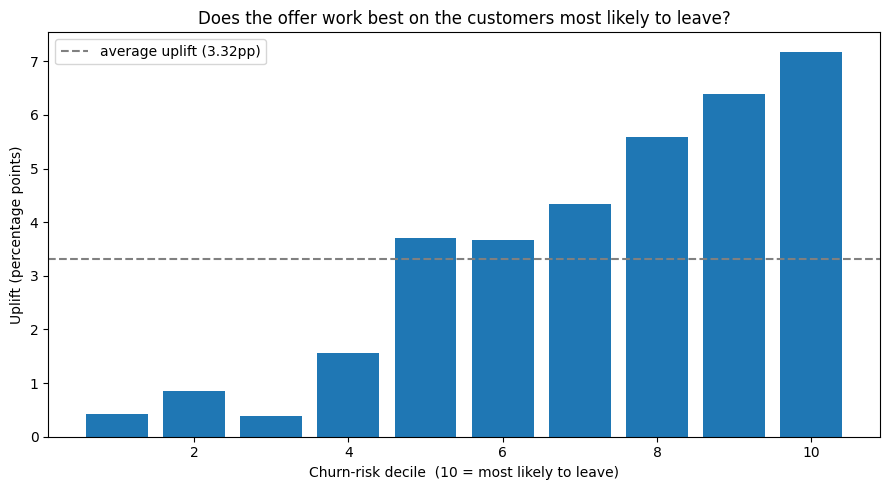

In [36]:
val_scored = val.copy()
val_scored['churn_risk'] = models['catboost'].predict_proba(X_va_u)[:, 1]
val_scored['risk_decile'] = pd.qcut(val_scored['churn_risk'], 10, labels=False) + 1

dec = val_scored.groupby('risk_decile').apply(
    lambda g: pd.Series({
        'n': len(g),
        'churn_risk': g['churn_risk'].mean(),
        'uplift': (g.loc[g.treatment == 1, 'target'].mean()
                   - g.loc[g.treatment == 0, 'target'].mean()),
        'avg_spend': g['total_spend'].mean(),
    })
).round(4)

print(dec)

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(dec.index, dec['uplift'] * 100)
ax.axhline(3.32, ls='--', color='grey', label='average uplift (3.32pp)')
ax.set_xlabel('Churn-risk decile  (10 = most likely to leave)')
ax.set_ylabel('Uplift (percentage points)')
ax.set_title('Does the offer work best on the customers most likely to leave?')
ax.legend()
plt.tight_layout()
plt.savefig(f'{PROJECT}/figures/uplift_by_risk_decile.png', dpi=120)
plt.show()

**Observations**

* **Uplift rises monotonically with churn risk.** The lowest-risk decile shows
  0.43pp, the highest 7.18pp — a sixteen-fold difference, with no reversal
  across the ten groups.

* **This contradicts the project's opening premise.** The framing argued that
  targeting the customers most likely to leave is the wrong approach, because
  many are already lost. In this dataset it is close to the right approach.
  Deciles 8, 9 and 10 all exceed the 3.32pp average, and deciles 1 to 4 are well
  below it.

* The likely reason is the selection property found in EDA. No campaign customer
  had been inactive for more than 22 days, so this population contains no
  genuinely lost customers. The "already gone" quadrant — the group that makes
  churn-risk targeting fail elsewhere — is absent by construction. What the model
  calls high risk here means wavering, not departed, and wavering customers are
  exactly who a message moves.

* Deciles 1 to 3 show almost no response at all, between 0.38pp and 0.85pp.
  These are the sure things: 95% likely to return anyway, and an offer changes
  nothing. Contacting them is pure waste, and this the project did predict
  correctly.

* **Value runs in the opposite direction to response.** Average spend falls from
  ₽18,279 in decile 1 to ₽2,024 in decile 10. The customers who respond most are
  worth the least. Targeting purely on uplift would concentrate spend on
  low-value customers, which is why the budget analysis must weight response by
  customer value rather than ranking on uplift alone.

* This also explains why the uplift models beat churn-risk ranking by only 29%
  rather than a wide margin. The two rankings largely agree here. The uplift
  models' advantage comes from the finer distinctions they make within risk
  bands, not from disagreeing about which bands matter.

* **The honest conclusion:** in a population of currently active customers, churn
  risk is a good proxy for responsiveness. The argument against risk-based
  targeting applies to populations containing lapsed customers, which this
  dataset does not. Uplift modelling still adds value, but less than the
  standard framing suggests.

### 7.6 Budget-constrained targeting

The decile chart showed response rising with churn risk, and value falling in
the opposite direction. The customers who respond most are worth the least.

Neither ranking alone is therefore correct. Ranking by response concentrates
spend on low-value customers. Ranking by value spends on customers who would
have returned anyway.

This section compares targeting policies under a fixed budget, measuring what
each actually delivers:

**Random** — the floor.
**Churn risk** — the standard retention approach.
**Uplift** — ranking by predicted response.
**Expected value** — uplift multiplied by customer spend.

For each policy, customers are ranked, the top N are "contacted", and the
incremental purchases within that group are measured by comparing treated and
control outcomes. The comparison is valid only because assignment was random.

In [37]:
te = test.copy()
te['churn_risk'] = models['catboost'].predict_proba(X_te_u)[:, 1]

s_learner = SoloModel(estimator=cbs(42))
s_learner.fit(X_tr_u, y_tr_u, t_tr)
te['uplift_score'] = s_learner.predict(X_te_u)
te['value_score']  = te['uplift_score'] * te['total_spend']

def policy_curve(d, score_col, steps=20):
    d = d.sort_values(score_col, ascending=False)
    out = []
    for i in range(1, steps + 1):
        k = int(len(d) * i / steps)
        top = d.iloc[:k]
        nt, nc = (top.treatment == 1).sum(), (top.treatment == 0).sum()
        if nt == 0 or nc == 0: continue
        lift = (top.loc[top.treatment == 1, 'target'].mean()
                - top.loc[top.treatment == 0, 'target'].mean())
        val_lift = lift * top['total_spend'].mean()
        out.append({'pct': i/steps, 'n': k, 'uplift': lift,
                    'incr_per_1000': lift*1000,
                    'incr_value_per_1000': val_lift*1000})
    return pd.DataFrame(out)

np.random.seed(42)
te['random_score'] = np.random.rand(len(te))

policies = {p: policy_curve(te, f'{p}_score' if p != 'churn' else 'churn_risk')
            for p in ['random', 'churn', 'uplift', 'value']}

summary = pd.DataFrame({
    p: c.set_index('pct')['incr_per_1000'] for p, c in policies.items()
}).round(1)
summary.head(10)

,random,churn,uplift,value
pct,,,,
0.05,38.0,31.7,146.6,51.4
0.10,33.3,62.0,107.9,51.5
0.15,42.4,40.9,87.5,34.8
0.20,42.3,39.8,77.6,35.4
0.25,38.4,36.2,59.9,32.4
0.30,36.2,40.7,49.8,31.3
0.35,31.5,48.0,50.7,27.4
0.40,34.9,43.2,49.0,31.3
0.45,34.6,47.7,44.4,31.6


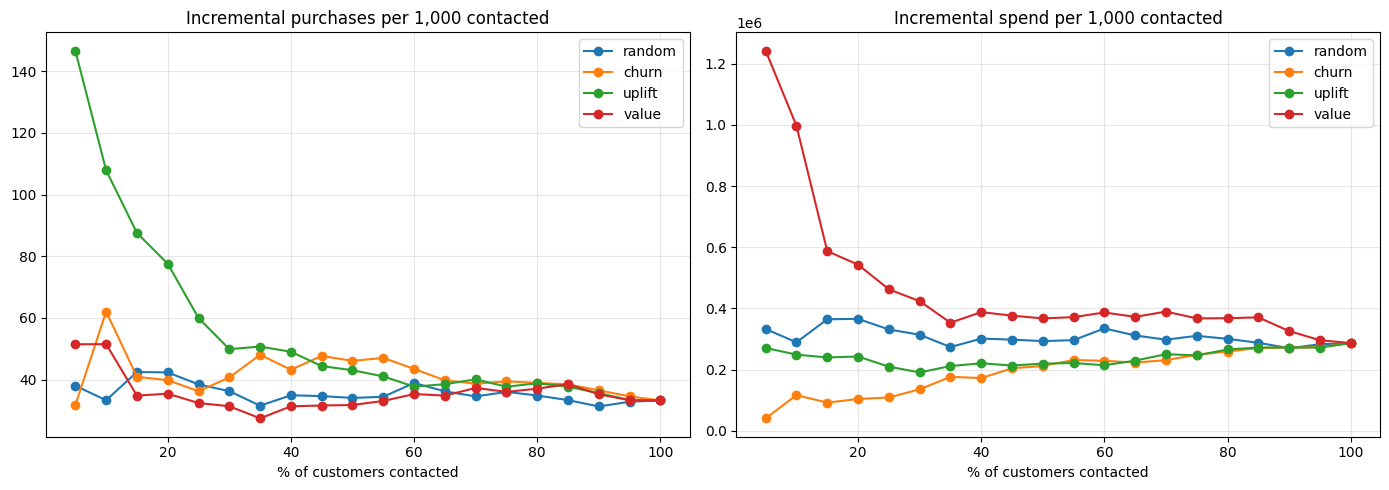

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for p, c in policies.items():
    axes[0].plot(c['pct']*100, c['incr_per_1000'], marker='o', label=p)
    axes[1].plot(c['pct']*100, c['incr_value_per_1000'], marker='o', label=p)

axes[0].set_title('Incremental purchases per 1,000 contacted')
axes[1].set_title('Incremental spend per 1,000 contacted')
for ax in axes:
    ax.set_xlabel('% of customers contacted'); ax.legend(); ax.grid(alpha=.3)
plt.tight_layout()
plt.savefig(f'{PROJECT}/figures/targeting_policies.png', dpi=120)
plt.show()

**Observations — incremental purchases**

* **At a 5% budget, uplift targeting delivers 146.6 incremental purchases per
  1,000 contacted, against 31.7 for churn-risk ranking and 38.0 for random.**
  That is 4.6× the churn-risk approach and 3.9× random.

* The advantage persists across small budgets: 107.9 against 62.0 at 10%, 87.5
  against 40.9 at 15%, 77.6 against 39.8 at 20%. Uplift targeting leads
  everywhere the budget is genuinely constrained.

* By 45% of customers contacted the curves converge, and beyond that all four
  policies are equivalent. This is expected — once you contact almost everyone,
  ranking no longer matters.

* **This is where the project's claim actually holds.** The decile chart showed
  churn risk correlating with response, which suggested the two approaches
  should be similar. They are not, because the uplift model makes finer
  distinctions *within* risk bands. Ranking by risk gets the direction right;
  ranking by uplift gets the order right.

* Churn-risk targeting is erratic at low budgets, scoring 31.7 at 5% and then
  62.0 at 10% — worse than random at its smallest slice. Uplift targeting
  declines smoothly, which is what a well-ordered ranking looks like.

**Observations — incremental spend**

* **The ranking inverts completely when value is included.** Value-based
  targeting delivers ₽1.24M incremental spend per 1,000 at a 5% budget, while
  uplift targeting delivers ₽0.27M and churn-risk targeting only ₽0.04M.

* Uplift targeting is the *worst* policy on this measure across most of the
  range, below even random. It finds the most responsive customers, and those
  customers are the least valuable — average spend fell from ₽18,279 in the
  lowest risk decile to ₽2,024 in the highest.

* Churn-risk targeting is worst of all at small budgets, at roughly a thirtieth
  of the value policy. It concentrates on high-risk, low-value customers.

* **The practical conclusion:** neither response nor risk is sufficient alone.
  Ranking by expected value — predicted uplift multiplied by customer spend —
  produces 4.6× the incremental revenue of the pure uplift ranking at a 5%
  budget. Which policy is correct depends on whether the business is measured
  on transactions or on revenue, and the two answers are opposite.

In [39]:
te.to_parquet(f'{PROJECT}/processed/test_scored_final.parquet')
joblib.dump(s_learner, f'{PROJECT}/models/l3_slearner.pkl')

for p, c in policies.items():
    c.to_csv(f'{PROJECT}/processed/policy_{p}.csv', index=False)
print('saved')

saved


### 7.7 Cost-constrained targeting

The policy curves show incremental purchases and revenue per 1,000 contacted,
but not whether contacting anyone is worth doing. That depends on what a
contact costs and what a purchase is worth.

Three assumptions are required, and all three are stated rather than hidden:

* **Cost per SMS.** Assumed at ₽5, a plausible bulk messaging rate.
* **Gross margin.** Assumed at 22%, typical for grocery retail.
* **Value of an incremental purchase.** Taken from each customer's own average
  basket rather than a single figure, since basket size varies enormously.

None of these come from the data. The dataset records only whether a customer
purchased, not what they spent afterwards. The financial layer is therefore a
translation of a real result into money under stated assumptions, not a measured
outcome.

**Sensitivity is reported alongside.** The optimal number of customers to
contact is recomputed at several cost levels, because the conclusion depends on
an assumption rather than a measurement. Showing how the answer moves with the
assumption is more useful than reporting one number as if it were fixed.

In [40]:
COST_PER_SMS = 5
MARGIN = 0.22

def profit_curve(d, score_col, cost, margin, steps=20):
    d = d.sort_values(score_col, ascending=False)
    out = []
    for i in range(1, steps+1):
        k = int(len(d)*i/steps)
        top = d.iloc[:k]
        nt, nc = (top.treatment==1).sum(), (top.treatment==0).sum()
        if nt == 0 or nc == 0: continue
        lift = top.loc[top.treatment==1,'target'].mean() - top.loc[top.treatment==0,'target'].mean()
        basket = top['avg_spend'].mean()
        gross = lift * basket * margin * k
        out.append({'pct': i/steps, 'n_contacted': k,
                    'incr_purchases': lift*k,
                    'gross_profit': gross,
                    'campaign_cost': cost*k,
                    'net_profit': gross - cost*k})
    return pd.DataFrame(out)

for p, col in [('uplift','uplift_score'), ('value','value_score'),
               ('churn','churn_risk'), ('random','random_score')]:
    c = profit_curve(te, col, COST_PER_SMS, MARGIN)
    best = c.loc[c['net_profit'].idxmax()]
    print(f"{p:<8} best at {best['pct']:.0%} contacted  "
          f"net ₽{best['net_profit']:>12,.0f}  "
          f"cost per incr. purchase ₽{best['campaign_cost']/best['incr_purchases']:>7,.0f}")

uplift   best at 20% contacted  net ₽       8,080  cost per incr. purchase ₽     64
value    best at 10% contacted  net ₽      19,127  cost per incr. purchase ₽     97
churn    best at 45% contacted  net ₽       9,433  cost per incr. purchase ₽    105
random   best at 5% contacted  net ₽      -1,259  cost per incr. purchase ₽    132


**Observations**

* **Value-based targeting is the most profitable policy**, producing ₽19,127 net
  at a 10% budget — roughly double churn-risk targeting (₽9,433) and uplift
  targeting (₽8,080).

* **Random targeting loses money at every budget level.** Its best case is
  −₽1,259. Untargeted campaigns are not merely inefficient here; they destroy
  value. Sending an SMS to everyone would cost more than the incremental
  purchases return.

* The optimal budget differs sharply by policy. Value targeting peaks at 10% of
  customers, uplift at 20%, churn risk at 45%. A policy that ranks well
  concentrates its return at the top and should stop early; a weaker ranking has
  to contact more people to accumulate the same return.

* Churn-risk targeting reaching its peak at 45% is itself the argument against
  it. It needs to contact four and a half times as many customers as value
  targeting to produce half the profit.

* **Cost per incremental purchase runs opposite to profit.** Uplift targeting
  is cheapest at ₽64, value targeting costs ₽97. Uplift finds the customers who
  respond most cheaply, but those customers buy small baskets. Optimising for
  cost per acquisition would select the less profitable policy.

* The absolute figures are small because the test set holds 30,006 customers.
  Scaled to the full campaign of 200,039, value targeting at a 10% budget would
  return roughly ₽127,000 net. The ratios between policies are the meaningful
  part, not the totals.

* These numbers rest on three stated assumptions — ₽5 per SMS, 22% margin, and
  incremental purchases valued at each customer's historical average basket.
  Sensitivity to the cost assumption is examined below.

In [41]:
for cost in [1, 5, 20, 50, 100]:
    c = profit_curve(te, 'value_score', cost, MARGIN)
    best = c.loc[c['net_profit'].idxmax()]
    print(f"cost ₽{cost:>4}  →  contact {best['pct']:.0%}  "
          f"net ₽{best['net_profit']:>12,.0f}")

cost ₽   1  →  contact 85%  net ₽      83,159
cost ₽   5  →  contact 10%  net ₽      19,127
cost ₽  20  →  contact 5%  net ₽      -8,839
cost ₽  50  →  contact 5%  net ₽     -53,839
cost ₽ 100  →  contact 5%  net ₽    -128,839


**Observations**

* **The targeting decision is extremely sensitive to contact cost.** At ₽1 per
  message the optimal policy is to contact 85% of customers for ₽83,159 net. At
  ₽5 it collapses to 10% for ₽19,127. At ₽20 no budget level is profitable.

* **The break-even point sits between ₽5 and ₽20 per contact.** Above roughly
  ₽10, the campaign should not run at all. This is the single most
  decision-relevant number in the analysis, and it comes from an assumption
  rather than from the data.

* At ₽20 and above, the optimum shows as 5% with a negative value. This is the
  smallest slice the simulation evaluates, so it means the model is choosing the
  least bad option among unprofitable ones. The correct action there is to
  contact nobody.

* The pattern is intuitive once seen. Cheap messages should go to nearly
  everyone, since even weak responders return more than they cost. Expensive
  messages must go only to the few whose expected value clears the cost, and
  above a threshold no customer clears it.

* **This is why the model matters more as costs rise.** At ₽1 the ranking is
  nearly irrelevant — contact everyone. At ₽5 it determines whether ₽19,127 is
  earned or lost. The value of targeting is proportional to the cost of
  contacting.

* The interval between ₽5 and ₽20 is where the answer changes, so a real
  deployment would need the actual per-message cost before deciding. Reporting a
  single profit figure without this range would present a conclusion that
  depends entirely on an unverified assumption.

### 7.8 Results summary

**Layer 1 — Segmentation**

We found five types of customer. The groups were not cleanly separated in the
data — customers sit on a spread rather than in neat clusters — but the groups
still turned out to be useful. Non-return rates ranged from 18% in one group to
72% in another.

The most useful part was this. Two groups looked identical to the standard RFM
method, which is what most retailers use. One shops constantly and buys a
little. The other shops half as often and fills a trolley. Their non-return
rates differ by 12 points. RFM cannot tell them apart. The clustering can.

**Layer 2 — Retention**

We compared nine models. The best scored 0.679, the simplest scored 0.672, and
just sorting by "days since last visit" scored 0.572. So the extra features
helped, but the choice of model barely mattered.

We picked the simplest model because it was three times faster for almost the
same score.

One surprise. The two models scored the same but used completely different
features to get there. The tree model relied on recency. The linear model
almost ignored recency and relied on `silence_ratio` instead. Same answer,
different route.

**Layer 3 — Uplift**

We compared four ways of predicting who responds to an offer. Running each one
five times showed the differences between them were small and partly luck.

But all four beat the standard approach of targeting whoever is most likely to
leave.

**One finding went against our expectations.** We assumed the people most likely
to leave would respond worst, because many are already gone. The opposite was
true. Response rose steadily with risk, from 0.4 points in the safest group to
7.2 points in the riskiest.

The reason is in the data. No customer here had been quiet for more than 22
days. X5 only messaged people who were still shopping. So the "already gone"
customers who normally ruin risk-based targeting simply are not in this dataset.

**The main finding**

If you count purchases, targeting by predicted response works best. At a 5%
budget it gets 147 extra purchases per 1,000 people, against 32 for targeting by
churn risk. Nearly five times better.

If you count money, it flips. The people who respond most spend the least —
₽18,279 in the safest group against ₽2,024 in the riskiest. On revenue, ranking
by response × spend gets ₽1.24M per 1,000 people, against ₽0.27M for response
alone. Again nearly five times, but the other way round.

**With costs included**

Assuming ₽5 per message and 22% margin, ranking by response × spend earns
₽19,127 profit when contacting the top 10%. That is about double either
alternative.

Messaging everyone at random loses money at every budget level.

The campaign stops being worth running somewhere between ₽5 and ₽20 per message.

## 8. Limitations

**We only have 117 days of purchase history.** That is not long enough to see
whether someone left for good. Our label means "did not come back soon," not
"gone forever."

**Nobody in the campaign had been quiet for more than 22 days.** X5 only
messaged customers who were still shopping. So this dataset has no lapsed
customers at all. That is why targeting by churn risk worked here. With dormant
customers included, it probably would not.

**The outcome is only yes or no.** We know whether someone bought after the
campaign. We do not know how much they spent. Every money figure in this project
comes from applying their past average basket, which is an assumption, not a
measurement.

**Three numbers were assumed, not measured** — ₽5 per message, 22% margin, and
past basket size as the value of a new purchase. The profit conclusion changes
sign within a realistic range of the first one, which is why we showed how it
moves.

**The offer is a text message, not a membership.** A membership costs much more
per customer, so the response would need to be much larger to be worth it. The
method transfers. The economics do not.

**No product categories in this download.** So we could not measure whether a
customer is buying from fewer types of product over time, which would have been
a good early warning signal.

**This is a grocery chain, not a marketplace.** There are no sellers. In a
marketplace, a customer may leave because their favourite seller left, and no
discount fixes that. We could not study that here.

**The customer groups are not cleanly separated.** They are useful for making
decisions, but they are boundaries drawn across a continuous spread rather than
natural divisions. A different starting point would shift them somewhat.

In [42]:
app_cols = ['client_id','segment','treatment','target',
            'churn_risk','uplift_score','value_score',
            'total_spend','avg_spend','n_txn','recency','avg_gap',
            'n_stores','redeem_rate','age_clean']

app_df = te[app_cols].copy()

seg_names = {
    0: 'Frequent small-basket',
    1: 'Occasional large-basket',
    2: 'Older regular',
    3: 'High-value bulk',
    4: 'Lapsing light',
}
app_df['segment_name'] = app_df['segment'].map(seg_names)

app_df.to_parquet(f'{PROJECT}/app_data.parquet', index=False)
print(app_df.shape, round(app_df.memory_usage(deep=True).sum()/1e6, 1), 'MB')
app_df.head()

(30006, 16) 7.3 MB


,client_id,segment,treatment,target,churn_risk,uplift_score,value_score,total_spend,avg_spend,n_txn,recency,avg_gap,n_stores,redeem_rate,age_clean,segment_name
26086,2141282321,2,0,1,0.547286,0.024214,50.169075,2071.94,295.991429,7,5,8.000000,3,0.000000,28.0,Older regular
126058,a198a6a1b8,1,0,0,0.494185,0.032782,133.091433,4059.87,451.096667,9,2,13.500000,4,0.000000,38.0,Occasional large-basket
4229,0562abc348,2,1,1,0.229249,0.021374,118.019185,5521.64,368.109333,15,3,5.428571,2,0.000000,39.0,Older regular
84069,6b5b44c32a,4,0,0,0.814944,0.152472,92.393516,605.97,121.194000,5,11,22.750000,3,0.400000,38.0,Lapsing light
8847,0b4d0f7fe0,0,1,1,0.137052,0.019148,166.129888,8676.00,289.200000,30,1,3.448276,2,0.066667,51.0,Frequent small-basket


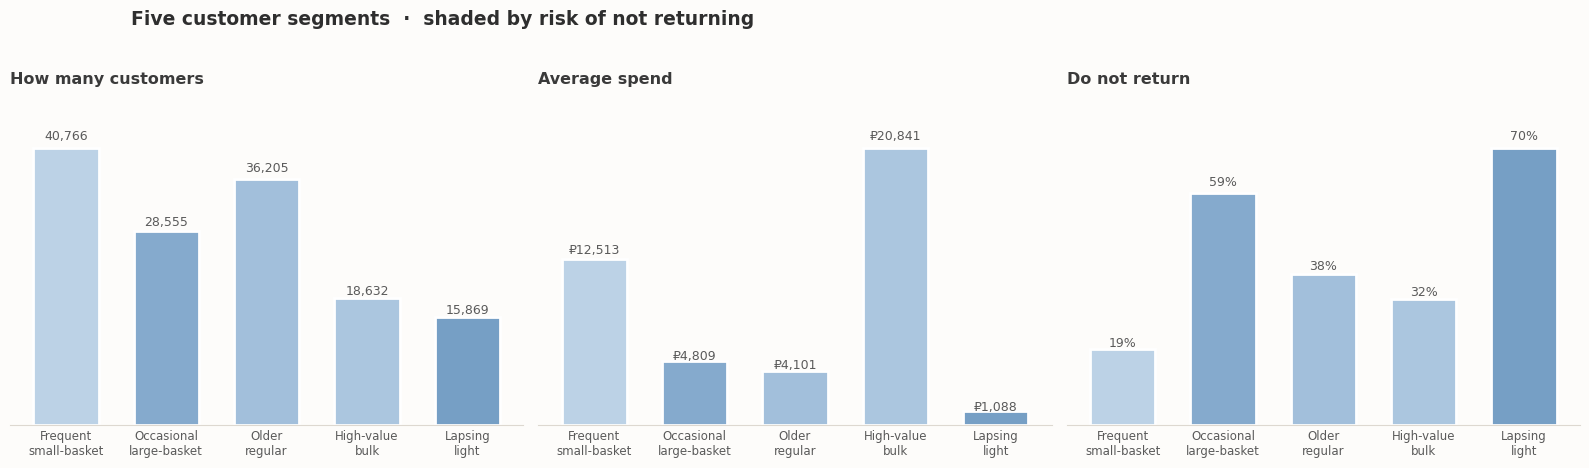

In [48]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

names = ['Frequent\nsmall-basket','Occasional\nlarge-basket','Older\nregular',
         'High-value\nbulk','Lapsing\nlight']

prof = train.groupby('segment').agg(
    size=('client_id','count'),
    spend=('total_spend','mean'),
).reset_index()
prof['risk'] = seg_risk['actual_rate'].values * 100
prof['name'] = names

# soft sage → sand → dusty rose
pastel = LinearSegmentedColormap.from_list(
    'blues', ['#D6E4F0', '#A9C4DE', '#7BA3C8', '#4E7FAF'])
colors = pastel(prof['risk'] / 100)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.patch.set_facecolor('#FDFCFA')

for ax, (col, title, fmt) in zip(axes, [
        ('size',  'How many customers', '{:,.0f}'),
        ('spend', 'Average spend',      '₽{:,.0f}'),
        ('risk',  'Do not return',      '{:.0f}%')]):
    ax.set_facecolor('#FDFCFA')
    bars = ax.bar(prof['name'], prof[col], color=colors,
                  edgecolor='white', linewidth=2, width=0.65)
    ax.set_title(title, fontsize=11.5, weight='600', loc='left',
                 pad=14, color='#3A3A3A')
    for b, v in zip(bars, prof[col]):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()*1.03,
                fmt.format(v), ha='center', fontsize=9,
                color='#5A5A5A', weight='500')
    ax.spines[['top','right','left']].set_visible(False)
    ax.spines['bottom'].set_color('#DDD8D0')
    ax.set_yticks([])
    ax.tick_params(axis='x', labelsize=8.5, colors='#5A5A5A', length=0)
    ax.set_ylim(0, prof[col].max()*1.16)

fig.suptitle('Five customer segments  ·  shaded by risk of not returning',
             fontsize=13.5, weight='600', x=0.085, ha='left', y=1.03,
             color='#2E2E2E')
plt.tight_layout()
plt.savefig(f'{PROJECT}/figures/segment_profiles.png', dpi=150,
            bbox_inches='tight', facecolor='#FDFCFA')
plt.show()